<img src = "https://drive.google.com/uc?export=view&id=1HYrQHu1AE2cEid3BpNxo5KK3tuZF1TCo" alt = "Encabezado MLDS" width = "100%">  </img>

# **Análisis de datos**
---

**Proyecto aplicado — Fase 4** · Conjunto de datos **I-CARE v2.1** (PhysioNet), metadatos clínicos de 607 pacientes en coma tras paro cardíaco.

Esta entrega toma el conjunto preparado en la fase 3 (`clinical_prepared.csv`) y extrae información de él mediante estadística descriptiva, análisis de asociación, modelos de regresión y contrastes de hipótesis, cerrando con visualizaciones estáticas e interactivas.

## **0. Integrantes del equipo de trabajo**
---

Por favor incluya los nombres completos y número de identificación de los integrantes del equipo de trabajo:

1. **Alejandra Jaramillo Mejía** — C.C. ---**INGRESE SU RESPUESTA**---
2. **Santiago Chaparro Suzunaga** — C.C. ---**INGRESE SU RESPUESTA**---
3. **Brayan Sebastián Yepes García** — C.C. ---**INGRESE SU RESPUESTA**---

## **Punto de partida: de dónde vienen estos datos**
---

Las tres fases anteriores dejaron el conjunto en el estado que este análisis necesita, y sus decisiones condicionan todo lo que sigue:

| Fase | Resultado que hereda esta entrega |
|---|---|
| 1. Entendimiento del negocio | Pregunta rectora: **qué variables clínicas se relacionan con el desenlace neurológico tras un paro cardíaco**, y con qué fuerza. |
| 2. Entendimiento de los datos | 607 pacientes, 10 variables clínicas, 5 hospitales representados en el conjunto público de entrenamiento. Se verificó que `Outcome` se deriva de `CPC` por una regla determinista. |
| 3. Preparación de los datos | `clinical_prepared.csv`: 9 variables de análisis + variable de respuesta, tipadas y validadas, sin pérdida de registros. `CPC` apartada en `cpc_reference.csv` para evitar análisis circulares. Faltantes de `ROSC` y `TTM` conservados, con versiones derivadas de cobertura completa (`ROSC_cat`, `TTM_cat`). |

**Tres limitaciones declaradas en la fase 3 que gobiernan la interpretación de esta:**

1. **La ausencia de `ROSC` es estructural, no aleatoria.** El Hospital A no registra la variable en ninguno de sus 261 pacientes, y es además el centro con mejor desenlace. Cualquier comparación entre pacientes con y sin ese dato está confundida por el centro de procedencia.
2. **`Age` está censurada en 90 años.** Su tramo superior debe leerse como "90 años o más".
3. **El diseño es observacional.** Ninguna asociación medida aquí autoriza una lectura causal, y `TTM` en particular refleja una decisión terapéutica tomada por el equipo tratante en función del estado del paciente.

## **Preparación del entorno y carga del conjunto preparado**
---

El conjunto se relee con el esquema declarado en la fase 3, que restituye los tipos y el orden de las variables categóricas ordinales. Sin ese esquema, el identificador `Patient` perdería sus ceros a la izquierda y `ROSC_cat` perdería su relación de orden.

In [1]:
# Instalación de dependencias (solo necesario en Colab o entornos limpios)
# !pip install -q statsmodels plotly scikit-learn
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.proportion import proportion_confint, confint_proportions_2indep
from statsmodels.stats.multitest import multipletests
from statsmodels.miscmodels.ordinal_model import OrderedModel
from sklearn.metrics import roc_auc_score, roc_curve

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)

SEMILLA = 42
rng = np.random.default_rng(SEMILLA)

print("Python     :", sys.version.split()[0])
print("pandas     :", pd.__version__)
print("statsmodels:", sm.__version__)

Python     : 3.11.15
pandas     : 3.0.2
statsmodels: 0.15.0


In [2]:
def localizar_raiz(marcas=("requirements.txt", ".git", "data")):
    '''Sube por el árbol de directorios hasta encontrar la raíz del repositorio.'''
    actual = Path.cwd().resolve()
    for candidato in [actual, *actual.parents]:
        if any((candidato / m).exists() for m in marcas):
            if (candidato / "data").exists():
                return candidato
    raise FileNotFoundError(
        "No se encontró la raíz del repositorio. Si trabaja en Colab, monte Drive "
        "o suba 'clinical_prepared.csv' y 'cpc_reference.csv' y ajuste PROCESSED_DIR."
    )


ROOT = localizar_raiz()
PROCESSED_DIR = ROOT / "data" / "processed"
FIG_DIR = ROOT / "results" / "figures"
TAB_DIR = ROOT / "results" / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

print("Raíz del proyecto :", ROOT.name)
print("Datos preparados  :", PROCESSED_DIR.relative_to(ROOT))

Raíz del proyecto : mlda-project_
Datos preparados  : data/processed


In [3]:
# Esquema de lectura heredado de la fase 3: sin él, el CSV pierde tipos y orden.
ESQUEMA_CLINICO = {
    "Patient": "string",
    "Hospital": "category",
    "Sex": "category",
    "Outcome": "category",
    "OHCA": "category",
    "Shockable Rhythm": "category",
    "ROSC_cat": "category",
    "TTM_cat": "category",
}
ORDEN_ROSC_CAT = ["Rápido (1-10 min)", "Intermedio (11-30 min)",
                  "Prolongado (>30 min)", "Sin dato"]
ORDEN_TTM_CAT = ["33 °C", "36 °C", "Sin TTM"]


def cargar_clinical_prepared(ruta=None):
    ruta = ruta or (PROCESSED_DIR / "clinical_prepared.csv")
    df = pd.read_csv(ruta, dtype=ESQUEMA_CLINICO, index_col="Patient")
    df["ROSC_cat"] = pd.Categorical(df["ROSC_cat"], categories=ORDEN_ROSC_CAT, ordered=True)
    df["TTM_cat"] = pd.Categorical(df["TTM_cat"], categories=ORDEN_TTM_CAT, ordered=True)
    return df


clinical = cargar_clinical_prepared()
cpc_reference = pd.read_csv(PROCESSED_DIR / "cpc_reference.csv",
                            dtype={"Patient": "string"}, index_col="Patient")

# Verificaciones de integridad antes de analizar nada.
assert len(clinical) == 607, "El conjunto no tiene los 607 pacientes esperados."
assert clinical.index.is_unique, "Hay identificadores repetidos."
assert clinical.index.equals(cpc_reference.index), "Los índices de ambos conjuntos no coinciden."
assert "CPC" not in clinical.columns, "CPC no debe estar en el conjunto de análisis."
assert clinical["ROSC_cat"].isna().sum() == 0 and clinical["TTM_cat"].isna().sum() == 0

print(f"clinical      : {clinical.shape[0]} pacientes × {clinical.shape[1]} columnas")
print(f"cpc_reference : {cpc_reference.shape[0]} pacientes × {cpc_reference.shape[1]} columna")
print()
clinical.head()

clinical      : 607 pacientes × 10 columnas
cpc_reference : 607 pacientes × 1 columna



,Hospital,Age,Sex,ROSC,ROSC_cat,OHCA,Shockable Rhythm,TTM,TTM_cat,Outcome
Patient,,,,,,,,,,
0284,A,53.0,Male,NaN,Sin dato,True,True,33.0,33 °C,Good
0286,F,85.0,Female,7.0,Rápido (1-10 min),False,False,NaN,Sin TTM,Good
0296,A,48.0,Male,NaN,Sin dato,True,True,36.0,36 °C,Good
0299,A,45.0,Male,NaN,Sin dato,True,True,33.0,33 °C,Good
0303,D,51.0,Male,24.0,Intermedio (11-30 min),True,True,33.0,33 °C,Good


In [4]:
clinical.info()

<class 'pandas.DataFrame'>
Index: 607 entries, 0284 to 1020
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Hospital          607 non-null    category
 1   Age               607 non-null    float64 
 2   Sex               607 non-null    category
 3   ROSC              303 non-null    float64 
 4   ROSC_cat          607 non-null    category
 5   OHCA              607 non-null    category
 6   Shockable Rhythm  607 non-null    category
 7   TTM               509 non-null    float64 
 8   TTM_cat           607 non-null    category
 9   Outcome           607 non-null    category
dtypes: category(7), float64(3)
memory usage: 23.9+ KB


## **1. Análisis y resultados**
---

### **1.0. Técnicas estadísticas a aplicar**
---

La elección de cada técnica está determinada por el **tipo de las variables implicadas**, no por su disponibilidad en una librería. El conjunto combina dos variables numéricas (`Age`, `ROSC`), una ordinal (`ROSC_cat`, y `CPC` en el conjunto de referencia), cuatro nominales (`Hospital`, `Sex`, `OHCA`, `Shockable Rhythm`, `TTM_cat`) y una respuesta binaria (`Outcome`). Esa mezcla excluye de entrada el coeficiente de Pearson como medida general de asociación: solo es interpretable entre las dos numéricas.

| Pregunta del análisis | Técnica | Por qué esta y no otra |
|---|---|---|
| ¿Cómo se distribuye cada variable y cómo difiere entre desenlaces? | Descriptivos por grupo (mediana, RIC, frecuencias) | La asimetría de `ROSC` y la censura de `Age` desaconsejan describir con media y desviación únicamente |
| ¿Se asocian dos variables **categóricas**? | **V de Cramér** con corrección de sesgo + χ² de independencia | Normaliza χ² al rango [0, 1] y permite comparar pares con distinto número de niveles; la corrección evita sobreestimar en tablas con celdas pequeñas |
| ¿Se asocian dos variables **numéricas u ordinales**? | **ρ de Spearman** | Mide asociación monótona sin asumir linealidad ni normalidad; `ROSC` tiene asimetría de 1.85 y `CPC` es ordinal |
| ¿Difiere una variable **numérica** entre los dos desenlaces? | **U de Mann-Whitney** + tamaño de efecto **rango-biserial** | La normalidad se rechaza en ambos grupos (Shapiro-Wilk); el contraste de medianas no la exige. El tamaño de efecto acompaña siempre al *p*-valor |
| ¿Cuánto vale un parámetro poblacional? | **Intervalos de confianza**: Wilson para proporciones, *bootstrap* percentil para medianas | Wilson se comporta bien con proporciones extremas y muestras pequeñas, donde el IC normal produce límites fuera de [0, 1] |
| ¿Cuál es el efecto de cada variable **ajustado por las demás**? | **Regresión logística** (respuesta binaria) y **regresión ordinal** (respuesta `CPC`) | La respuesta no es continua: la regresión lineal produciría probabilidades fuera de [0, 1]. El modelo ordinal aprovecha los cinco niveles de severidad |
| ¿La asociación observada sobrevive al control por centro? | Comparación de **modelos anidados** con contraste de razón de verosimilitudes | Es la forma directa de contrastar si un bloque de variables aporta información más allá del azar |
| ¿Cuántos falsos positivos introduce la batería de contrastes? | Corrección de **Holm** | Se aplican ocho contrastes sobre la misma muestra; sin corrección, la probabilidad de al menos un falso positivo pasa del 5 % al 34 % |

**Nivel de significación.** Se fija α = 0.05 para todos los contrastes, declarado antes de ejecutarlos. Los *p*-valores se reportan siempre junto a un tamaño de efecto y un intervalo de confianza, porque un *p* pequeño en n = 607 puede corresponder a una diferencia clínicamente irrelevante.

### **1.0.1. Caracterización descriptiva de la cohorte**
---

Antes de medir asociaciones conviene saber a quién describen estos datos. La tabla siguiente sigue la convención de los estudios clínicos: cada fila es una variable, las columnas separan los dos desenlaces, y la última columna anticipa el contraste que se formaliza en la sección 1.3.

In [5]:
def resumen_numerica(serie, etiqueta):
    s = serie.dropna()
    return f"{s.median():.0f} [{s.quantile(.25):.0f}–{s.quantile(.75):.0f}]"


def tabla_caracteristicas(df, grupo="Outcome"):
    '''Tabla 1 al estilo clínico: mediana [RIC] para numéricas, n (%) para categóricas.'''
    filas = []
    total = df
    g_good = df[df[grupo] == "Good"]
    g_poor = df[df[grupo] == "Poor"]

    filas.append({"Variable": "n", "Total": f"{len(total)}",
                  "Desenlace favorable": f"{len(g_good)}", "Desenlace desfavorable": f"{len(g_poor)}",
                  "Cobertura": "100 %"})

    for col, nombre in [("Age", "Edad, años — mediana [RIC]"),
                        ("ROSC", "ROSC, min — mediana [RIC]")]:
        cob = df[col].notna().mean()
        filas.append({"Variable": nombre,
                      "Total": resumen_numerica(total[col], col),
                      "Desenlace favorable": resumen_numerica(g_good[col], col),
                      "Desenlace desfavorable": resumen_numerica(g_poor[col], col),
                      "Cobertura": f"{cob:.1%}"})

    for col in ["Sex", "Hospital", "OHCA", "Shockable Rhythm", "ROSC_cat", "TTM_cat"]:
        for nivel in df[col].cat.categories:
            n_t = (total[col] == nivel).sum()
            n_g = (g_good[col] == nivel).sum()
            n_p = (g_poor[col] == nivel).sum()
            if n_t == 0:
                continue
            filas.append({
                "Variable": f"{col} = {nivel}",
                "Total": f"{n_t} ({n_t/len(total):.1%})",
                "Desenlace favorable": f"{n_g} ({n_g/len(g_good):.1%})",
                "Desenlace desfavorable": f"{n_p} ({n_p/len(g_poor):.1%})",
                "Cobertura": "100 %",
            })
    return pd.DataFrame(filas).set_index("Variable")


tabla1 = tabla_caracteristicas(clinical)
tabla1.to_csv(TAB_DIR / "tabla1_caracteristicas.csv")
tabla1

,Total,Desenlace favorable,Desenlace desfavorable,Cobertura
Variable,,,,
n,607,225,382,100 %
"Edad, años — mediana [RIC]",63 [52–72],58 [49–67],66 [54–75],100.0%
"ROSC, min — mediana [RIC]",19 [10–30],15 [8–25],20 [11–30],49.9%
Sex = Female,187 (30.8%),62 (27.6%),125 (32.7%),100 %
Sex = Male,420 (69.2%),163 (72.4%),257 (67.3%),100 %
Hospital = A,261 (43.0%),122 (54.2%),139 (36.4%),100 %
Hospital = B,120 (19.8%),34 (15.1%),86 (22.5%),100 %
Hospital = D,83 (13.7%),27 (12.0%),56 (14.7%),100 %
Hospital = E,74 (12.2%),15 (6.7%),59 (15.4%),100 %


In [6]:
# Distribución de la variable de respuesta y de la escala ordinal apartada.
n = len(clinical)
n_good = int((clinical["Outcome"] == "Good").sum())
p_good = n_good / n
lo, hi = proportion_confint(n_good, n, method="wilson")

print(f"Desenlace favorable: {n_good}/{n} = {p_good:.3f}  (IC 95 % Wilson: {lo:.3f}–{hi:.3f})")
print(f"Desenlace desfavorable: {n - n_good}/{n} = {1 - p_good:.3f}")
print()
print("Distribución de CPC (conjunto de referencia, 5 niveles de severidad):")
dist_cpc = cpc_reference["CPC"].value_counts().sort_index()
for nivel, cuenta in dist_cpc.items():
    print(f"  CPC {nivel}: {cuenta:3d} pacientes ({cuenta/n:5.1%})")
print()
print(f"Edad: mediana {clinical['Age'].median():.0f} años, "
      f"RIC {clinical['Age'].quantile(.25):.0f}–{clinical['Age'].quantile(.75):.0f}, "
      f"rango {clinical['Age'].min():.0f}–{clinical['Age'].max():.0f} (censurada en 90)")
print(f"Asimetría de Age  : {clinical['Age'].skew():.3f}")
print(f"Asimetría de ROSC : {clinical['ROSC'].skew():.3f}  (n = {clinical['ROSC'].notna().sum()})")

Desenlace favorable: 225/607 = 0.371  (IC 95 % Wilson: 0.333–0.410)
Desenlace desfavorable: 382/607 = 0.629

Distribución de CPC (conjunto de referencia, 5 niveles de severidad):
  CPC 1: 181 pacientes (29.8%)
  CPC 2:  44 pacientes ( 7.2%)
  CPC 3:  20 pacientes ( 3.3%)
  CPC 4:   9 pacientes ( 1.5%)
  CPC 5: 353 pacientes (58.2%)

Edad: mediana 63 años, RIC 52–72, rango 16–90 (censurada en 90)
Asimetría de Age  : -0.593
Asimetría de ROSC : 1.847  (n = 303)


**Lectura de la caracterización**

La cohorte es mayoritariamente masculina (69.2 %) y de edad avanzada (mediana 63 años, RIC 52–72). El desenlace favorable ocurre en 225 de los 607 pacientes, un 37.1 % con intervalo de confianza del 95 % entre 33.3 % y 41.0 %. El intervalo es estrecho, del orden de ocho puntos porcentuales, lo que indica que el tamaño de muestra es suficiente para estimar la tasa global con precisión razonable.

La distribución de `CPC` revela una estructura que la versión binaria oculta: los 382 pacientes con desenlace desfavorable no se reparten de forma gradual entre los niveles 3, 4 y 5, sino que **353 de ellos (el 92 %) están en el nivel 5, que corresponde a muerte**. Los niveles intermedios 3 y 4 reúnen apenas 29 pacientes. El desenlace desfavorable en esta cohorte es, casi siempre, la forma más extrema de ese desenlace. Esta observación justifica por sí sola la decisión de la fase 3 de conservar `CPC` como referencia: la dicotomización es adecuada para el análisis principal, pero pierde el hecho de que la clase desfavorable está dominada por un único nivel.

La asimetría contrasta entre las dos variables numéricas: −0.59 en `Age`, moderada y compatible con una cohorte concentrada en edades altas, frente a 1.85 en `ROSC`, marcadamente positiva. Esa diferencia es la que motiva emplear medianas y contrastes de rango en lugar de medias y pruebas *t*.

### **1.1. Análisis de correlaciones**
---

- Analice la posible existencia de relaciones entre las variables, utilizando medidas de correlación o visualizaciones pertinentes.
- Detecte la presencia de redundancias entre las variables, con el objetivo de facilitar su posterior eliminación o selección en el análisis.
- ¿Cuáles fueron las variables seleccionadas para el análisis de correlaciones, y cómo se eligieron en función de los objetivos del proyecto?

**Variables seleccionadas y criterio de selección**

Entran al análisis de asociación **las diez variables del conjunto preparado más `CPC`**, que se incorpora aquí de forma deliberada y por una sola vez: su correlación con `Outcome` es precisamente lo que permite verificar de manera cuantitativa la redundancia que la fase 3 dedujo de la definición del estudio. Fuera de esta verificación, ambas no vuelven a aparecer juntas en ningún análisis.

`Patient` queda excluida por ser un identificador sin contenido clínico.

La selección no descarta ninguna variable *a priori* por su porcentaje de faltantes ni por su baja asociación esperada. El objetivo de esta sección no es filtrar predictores para un modelo, sino **mapear la estructura de dependencias del conjunto**, incluidas las que existen entre variables explicativas y que condicionarán la interpretación de la regresión: una asociación fuerte entre `Hospital` y `ROSC_cat` no dice nada sobre el pronóstico, pero determina si los coeficientes del modelo pueden leerse por separado.

In [7]:
def cramers_v(x, y, corregido=True):
    '''V de Cramér entre dos variables categóricas, con corrección de sesgo de
    Bergsma-Wicher. Devuelve un valor en [0, 1]: 0 = independencia.'''
    tabla = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(tabla)[0]
    n = tabla.values.sum()
    phi2 = chi2 / n
    r, k = tabla.shape
    if corregido:
        phi2 = max(0.0, phi2 - (k - 1) * (r - 1) / (n - 1))
        r = r - (r - 1) ** 2 / (n - 1)
        k = k - (k - 1) ** 2 / (n - 1)
    denom = max(1e-12, min(k - 1, r - 1))
    return float(np.sqrt(phi2 / denom))


# Marco categórico: las seis categóricas del conjunto, la respuesta y CPC como referencia.
cat_frame = clinical[["Hospital", "Sex", "OHCA", "Shockable Rhythm",
                      "ROSC_cat", "TTM_cat", "Outcome"]].astype(str).copy()
cat_frame["CPC"] = cpc_reference["CPC"].astype(str)

matriz_v = pd.DataFrame(index=cat_frame.columns, columns=cat_frame.columns, dtype=float)
for a in cat_frame.columns:
    for b in cat_frame.columns:
        matriz_v.loc[a, b] = cramers_v(cat_frame[a], cat_frame[b])

matriz_v.to_csv(TAB_DIR / "matriz_cramer_v.csv")
print("Matriz de asociación — V de Cramér corregida (0 = independencia, 1 = dependencia total)")
matriz_v.round(3)

Matriz de asociación — V de Cramér corregida (0 = independencia, 1 = dependencia total)


,Hospital,Sex,OHCA,Shockable Rhythm,ROSC_cat,TTM_cat,Outcome,CPC
Hospital,1.000,0.027,0.255,0.302,0.536,0.566,0.183,0.111
Sex,0.027,0.996,0.000,0.041,0.069,0.000,0.030,0.000
OHCA,0.255,0.000,1.000,0.498,0.247,0.351,0.000,0.062
Shockable Rhythm,0.302,0.041,0.498,1.000,0.260,0.427,0.379,0.289
ROSC_cat,0.536,0.069,0.247,0.260,1.000,0.142,0.204,0.126
TTM_cat,0.566,0.000,0.351,0.427,0.142,1.000,0.000,0.039
Outcome,0.183,0.030,0.000,0.379,0.204,0.000,0.996,0.998
CPC,0.111,0.000,0.062,0.289,0.126,0.039,0.998,1.000


In [8]:
# Asociaciones entre las variables numéricas y ordinales: rho de Spearman.
orden_num = pd.DataFrame({
    "Age": clinical["Age"],
    "ROSC": clinical["ROSC"],
    "CPC": cpc_reference["CPC"].astype(float),
    "Outcome_Good": (clinical["Outcome"] == "Good").astype(int),
})

spearman = orden_num.corr(method="spearman")
print("Correlación de Spearman (pares completos)")
print(spearman.round(3).to_string())

print("\nCon su significación:")
for a, b in [("Age", "ROSC"), ("Age", "CPC"), ("ROSC", "CPC"),
             ("Age", "Outcome_Good"), ("ROSC", "Outcome_Good"), ("CPC", "Outcome_Good")]:
    sub = orden_num[[a, b]].dropna()
    rho, p = stats.spearmanr(sub[a], sub[b])
    print(f"  {a:12s} ~ {b:12s}  n = {len(sub):3d}   rho = {rho:+.3f}   p = {p:.2e}")

Correlación de Spearman (pares completos)
                Age   ROSC    CPC  Outcome_Good
Age           1.000 -0.124  0.210        -0.215
ROSC         -0.124  1.000  0.141        -0.143
CPC           0.210  0.141  1.000        -0.949
Outcome_Good -0.215 -0.143 -0.949         1.000

Con su significación:
  Age          ~ ROSC          n = 303   rho = -0.124   p = 3.05e-02
  Age          ~ CPC           n = 607   rho = +0.210   p = 1.67e-07
  ROSC         ~ CPC           n = 303   rho = +0.141   p = 1.39e-02
  Age          ~ Outcome_Good  n = 607   rho = -0.215   p = 8.74e-08
  ROSC         ~ Outcome_Good  n = 303   rho = -0.143   p = 1.27e-02
  CPC          ~ Outcome_Good  n = 607   rho = -0.949   p = 1.58e-306


**Qué muestra la matriz de asociación**

Tres bloques de resultados, en orden de importancia para el proyecto:

**1. La asociación de cada variable con el desenlace.** `Shockable Rhythm` es, con diferencia, la variable más asociada al desenlace neurológico (V = 0.379), seguida a distancia por `ROSC_cat` (V = 0.204) y `Hospital` (V = 0.183). `Sex` (V = 0.030), `OHCA` y `TTM_cat` (ambas V = 0 tras la corrección de sesgo) no muestran asociación apreciable. Estas tres últimas no quedan excluidas del análisis: la ausencia de asociación **marginal** no impide que una variable resulte relevante una vez ajustada por las demás, y la sección 1.2 mostrará que eso es exactamente lo que ocurre con `TTM_cat`.

**2. Las asociaciones entre variables explicativas.** `Hospital` está fuertemente asociada a `TTM_cat` (V = 0.566) y a `ROSC_cat` (V = 0.536). Ninguna de las dos es un hallazgo clínico: son la huella del protocolo de registro de cada centro. El Hospital A no registra `ROSC` en ninguno de sus 261 pacientes, de modo que saber el centro determina en buena medida si el dato existe. Esta dependencia es la fuente de confusión declarada en la fase 3, y obliga a incluir `Hospital` en cualquier modelo que pretenda leer el efecto de `ROSC`.

**3. La redundancia entre `Outcome` y `CPC`.** V = 0.998 y ρ de Spearman = −0.949 con *p* < 10⁻²⁹⁰. Las dos variables miden lo mismo. El valor no alcanza exactamente 1 solo porque la V de Cramér corregida penaliza el tamaño de la tabla, no porque exista alguna discrepancia entre ellas: la fase 2 verificó que la regla CPC ∈ {1,2} → favorable y CPC ∈ {3,4,5} → desfavorable se cumple sin una sola excepción en los 607 registros. El signo negativo de ρ es de lectura directa: a mayor nivel de `CPC` (mayor daño neurológico), menor probabilidad de desenlace favorable.

En cuanto a las numéricas, la edad muestra una asociación monótona débil pero significativa con el desenlace (ρ = −0.215 con `Outcome_Good`, *p* = 9×10⁻⁸) y con la severidad (ρ = +0.210 con `CPC`). `ROSC` se comporta en la misma dirección esperada (ρ = −0.143 con el desenlace), aunque su correlación solo puede calcularse sobre los 303 pacientes que tienen el dato. La correlación entre `Age` y `ROSC` es débil (ρ = −0.124), lo que descarta que ambas aporten la misma información.

**Redundancias detectadas y decisión sobre cada una**

| Par redundante | Medida | Decisión |
|---|---|---|
| `Outcome` ↔ `CPC` | V = 0.998; ρ = −0.949 | **Nunca juntas.** `Outcome` es la respuesta del análisis principal; `CPC` se reserva como respuesta alternativa del modelo ordinal de la sección 1.2.2 |
| `ROSC` ↔ `ROSC_cat` | Misma variable, distinta escala | **Una por análisis.** `ROSC_cat` en los modelos sobre la cohorte completa (cubre a los 607); `ROSC` numérica en los análisis restringidos a los 303 con dato |
| `TTM` ↔ `TTM_cat` | Misma variable, distinta escala | **Solo `TTM_cat`.** La numérica toma dos valores (33 y 36) y la categórica los representa sin pérdida, añadiendo el grupo "Sin TTM" |
| `Hospital` ↔ `ROSC_cat` / `TTM_cat` | V = 0.536 / 0.566 | **No es redundancia, es confusión.** Las tres se conservan; el efecto se cuantifica con los factores de inflación de varianza en la sección 1.2.1 |

La eliminación de redundancias reduce el conjunto de variables candidatas al modelo a siete: `Age`, `Sex`, `OHCA`, `Shockable Rhythm`, `ROSC_cat`, `TTM_cat` y `Hospital`.

### **1.2. Análisis de regresiones**
---

- A partir de las correlaciones identificadas, ¿es posible llevar a cabo un análisis de regresiones para estimar el valor de alguna de las variables de interés?
- ¿Cuáles fueron las variables seleccionadas para el análisis de regresiones y cómo se eligieron en función de los objetivos del proyecto?

**¿Es posible? Sí, pero no con una regresión lineal**

La variable de interés del proyecto es el desenlace neurológico, y es **binaria**. Ajustar sobre ella una regresión lineal tendría tres defectos conocidos: produciría probabilidades estimadas fuera del intervalo [0, 1], violaría el supuesto de homocedasticidad (la varianza de una variable de Bernoulli depende de su propia media) y dejaría residuos que no pueden ser normales porque la respuesta solo toma dos valores. La técnica que corresponde es la **regresión logística**, que modela el logaritmo de la razón de momios (*odds*) como función lineal de las variables explicativas y devuelve una probabilidad acotada.

Se ajustan tres modelos con un propósito específico cada uno:

| Modelo | Respuesta | Variables | Qué pregunta responde |
|---|---|---|---|
| **1.2.1 Logístico** | `Outcome` (favorable / desfavorable) | Las siete que sobrevivieron al filtro de redundancia | ¿Cuál es el efecto de cada variable clínica sobre la probabilidad de desenlace favorable, ajustado por las demás? |
| **1.2.2 Ordinal** | `CPC` (5 niveles de severidad) | Subconjunto de las mismas | ¿Se mantienen los efectos cuando se aprovecha la escala completa de severidad en lugar de la versión dicotomizada? |
| **1.2.3 Lineal (MCO)** | `log(1 + ROSC)` | Variables clínicas y centro | ¿Qué explica el tiempo hasta la recuperación de la circulación? Análisis secundario, restringido a los 303 pacientes con el dato |

**Variables seleccionadas y por qué.** Entran las siete que quedaron tras eliminar redundancias en la sección 1.1: `Age`, `Sex`, `OHCA`, `Shockable Rhythm`, `ROSC_cat`, `TTM_cat` y `Hospital`. Dos decisiones merecen justificación explícita:

- **`ROSC_cat` en lugar de `ROSC` numérica.** La versión numérica obligaría a descartar 304 pacientes (el 50 % de la cohorte) o a imputarlos. La categórica cubre a los 607 e incorpora la ausencia como categoría propia, lo que permite además estimar y leer por separado el comportamiento del grupo sin registro. La versión numérica se usa en el análisis de sensibilidad del final de la sección.
- **`Hospital` se incluye pese a no ser una variable clínica.** La sección 1.1 mostró que el centro determina en buena medida qué se registra y con qué protocolo se trata. Omitirlo dejaría sus efectos confundidos dentro de los coeficientes de `ROSC_cat` y `TTM_cat`. Su coeficiente no se interpreta como una propiedad de los pacientes, sino como el efecto combinado de composición de casos y práctica clínica de cada centro.

**Categorías de referencia** (heredadas de la fase 3): `Female` para `Sex`, `False` para `OHCA` y `Shockable Rhythm`, `33 °C` para `TTM_cat`, `Rápido (1-10 min)` para `ROSC_cat` y el Hospital `A` por ser el que más pacientes aporta.

#### **1.2.1. Regresión logística sobre el desenlace neurológico**

In [9]:
# Marco de modelado: nombres sin espacios ni tildes para las fórmulas de patsy.
modelo_df = clinical.copy()
modelo_df["y"] = (modelo_df["Outcome"] == "Good").astype(int)
modelo_df = modelo_df.rename(columns={"Shockable Rhythm": "Shockable"})
for col in ["Shockable", "OHCA", "Sex", "Hospital", "ROSC_cat", "TTM_cat"]:
    modelo_df[col] = modelo_df[col].astype(str)

F_BASAL = ("y ~ Age + C(Sex, Treatment('Female'))"
           " + C(Shockable, Treatment('False'))"
           " + C(OHCA, Treatment('False'))")
F_CLINICO = F_BASAL + (" + C(ROSC_cat, Treatment('Rápido (1-10 min)'))"
                       " + C(TTM_cat, Treatment('33 °C'))")
F_COMPLETO = F_CLINICO + " + C(Hospital, Treatment('A'))"

modelos = {}
resumen_modelos = []
for nombre, formula in [("M1 · basal", F_BASAL),
                        ("M2 · + ROSC/TTM", F_CLINICO),
                        ("M3 · + Hospital", F_COMPLETO)]:
    ajuste = smf.logit(formula, data=modelo_df).fit(disp=0)
    modelos[nombre] = ajuste
    resumen_modelos.append({
        "Modelo": nombre,
        "Parámetros": int(ajuste.df_model),
        "Log-verosimilitud": round(ajuste.llf, 2),
        "Pseudo-R² (McFadden)": round(ajuste.prsquared, 4),
        "AIC": round(ajuste.aic, 1),
        "BIC": round(ajuste.bic, 1),
        "AUC": round(roc_auc_score(modelo_df["y"], ajuste.predict(modelo_df)), 4),
    })

pd.DataFrame(resumen_modelos).set_index("Modelo")

,Parámetros,Log-verosimilitud,Pseudo-R² (McFadden),AIC,BIC,AUC
Modelo,,,,,,
M1 · basal,6,-341.58,0.1465,697.2,728.0,0.7569
M2 · + ROSC/TTM,11,-330.94,0.1731,685.9,738.8,0.7732
M3 · + Hospital,15,-323.78,0.1910,679.6,750.1,0.7863


In [10]:
def razon_verosimilitudes(completo, reducido):
    '''Contraste de razón de verosimilitudes entre dos modelos anidados.'''
    estadistico = 2 * (completo.llf - reducido.llf)
    gl = int(completo.df_model - reducido.df_model)
    p = 1 - stats.chi2.cdf(estadistico, gl)
    return estadistico, gl, p


for etiqueta, comp, red in [("M1 → M2 (aporte de ROSC_cat y TTM_cat)",
                             modelos["M2 · + ROSC/TTM"], modelos["M1 · basal"]),
                            ("M2 → M3 (aporte de Hospital)",
                             modelos["M3 · + Hospital"], modelos["M2 · + ROSC/TTM"])]:
    est, gl, p = razon_verosimilitudes(comp, red)
    veredicto = "aporta información" if p < 0.05 else "no aporta información"
    print(f"{etiqueta:45s}  LR = {est:6.2f}  gl = {gl}  p = {p:.5f}  →  {veredicto}")

M1 → M2 (aporte de ROSC_cat y TTM_cat)         LR =  21.28  gl = 5  p = 0.00072  →  aporta información
M2 → M3 (aporte de Hospital)                   LR =  14.31  gl = 4  p = 0.00636  →  aporta información


In [11]:
# Modelo final y sus razones de momios (odds ratios) con intervalo de confianza.
logit_final = modelos["M3 · + Hospital"]

ic = logit_final.conf_int()
tabla_or = pd.DataFrame({
    "Coeficiente (log-odds)": logit_final.params.round(4),
    "OR": np.exp(logit_final.params).round(3),
    "IC 95 % inferior": np.exp(ic[0]).round(3),
    "IC 95 % superior": np.exp(ic[1]).round(3),
    "p": logit_final.pvalues.round(4),
})
tabla_or.index = [i.replace("C(", "").replace(", Treatment(", " vs ")
                   .replace("))", "").replace("'", "").replace("[T.", " = ")
                   .replace("]", "") for i in tabla_or.index]
tabla_or.to_csv(TAB_DIR / "regresion_logistica_or.csv")

print(f"n = {int(logit_final.nobs)} pacientes · "
      f"contraste global LR p = {logit_final.llr_pvalue:.2e} · "
      f"pseudo-R² = {logit_final.prsquared:.3f}")
print(f"OR de la edad por cada 10 años adicionales: "
      f"{np.exp(logit_final.params['Age'] * 10):.3f}")
print()
tabla_or

n = 607 pacientes · contraste global LR p = 6.58e-25 · pseudo-R² = 0.191
OR de la edad por cada 10 años adicionales: 0.718



,Coeficiente (log-odds),OR,IC 95 % inferior,IC 95 % superior,p
Intercept,0.7235,2.062,0.459,9.258,0.3451
Sex vs Female = Male,0.2177,1.243,0.817,1.891,0.3087
Shockable vs False = Desconocido,1.2268,3.410,0.905,12.853,0.0700
Shockable vs False = True,1.9103,6.755,4.282,10.657,0.0000
OHCA vs False = Desconocido,-0.0756,0.927,0.267,3.214,0.9051
OHCA vs False = True,-0.3888,0.678,0.394,1.168,0.1611
ROSC_cat vs Rápido (1-10 min) = Intermedio (11-30 min),-0.9325,0.394,0.198,0.781,0.0077
ROSC_cat vs Rápido (1-10 min) = Prolongado (>30 min),-1.8934,0.151,0.058,0.388,0.0001
ROSC_cat vs Rápido (1-10 min) = Sin dato,0.0046,1.005,0.330,3.058,0.9936
TTM_cat vs 33 °C = 36 °C,-0.1816,0.834,0.387,1.795,0.6425


In [12]:
# Multicolinealidad: factores de inflación de varianza sobre la matriz de diseño.
X_dis = logit_final.model.exog
vif = pd.DataFrame({
    "Término": logit_final.model.exog_names,
    "VIF": [variance_inflation_factor(X_dis, i) for i in range(X_dis.shape[1])],
}).set_index("Término")
vif["Lectura"] = pd.cut(vif["VIF"], [0, 2.5, 5, 10, np.inf],
                        labels=["sin problema", "moderado", "alto", "crítico"])
vif.loc[vif.index != "Intercept"].round(2).sort_values("VIF", ascending=False)

,VIF,Lectura
Término,,
"C(ROSC_cat, Treatment('Rápido (1-10 min)'))[T.Sin dato]",8.51,alto
"C(Hospital, Treatment('A'))[T.F]",6.27,alto
"C(Hospital, Treatment('A'))[T.B]",5.76,alto
"C(Hospital, Treatment('A'))[T.E]",4.14,moderado
"C(Hospital, Treatment('A'))[T.D]",3.70,moderado
"C(TTM_cat, Treatment('33 °C'))[T.Sin TTM]",3.57,moderado
"C(Shockable, Treatment('False'))[T.Desconocido]",2.67,moderado
"C(OHCA, Treatment('False'))[T.Desconocido]",2.64,moderado
"C(ROSC_cat, Treatment('Rápido (1-10 min)'))[T.Intermedio (11-30 min)]",2.27,sin problema


In [13]:
# Calibración: prueba de Hosmer-Lemeshow sobre deciles de riesgo predicho.
p_pred = logit_final.predict(modelo_df)
deciles = pd.qcut(p_pred, 10, duplicates="drop")
hl = (pd.DataFrame({"p": p_pred, "y": modelo_df["y"], "g": deciles})
        .groupby("g", observed=True)
        .agg(n=("y", "size"), observados=("y", "sum"), esperados=("p", "sum")))
hl_stat = (((hl["observados"] - hl["esperados"]) ** 2)
           / (hl["esperados"] * (1 - hl["esperados"] / hl["n"]))).sum()
hl_gl = len(hl) - 2
hl_p = 1 - stats.chi2.cdf(hl_stat, hl_gl)

print(f"Hosmer-Lemeshow: χ² = {hl_stat:.3f}, gl = {hl_gl}, p = {hl_p:.4f}")
print("Un p ALTO indica buen ajuste: no hay evidencia de discrepancia entre "
      "lo observado y lo predicho.\n")
print(f"Discriminación (AUC): {roc_auc_score(modelo_df['y'], p_pred):.4f}")
print()
hl.round(2)

Hosmer-Lemeshow: χ² = 8.657, gl = 8, p = 0.3720
Un p ALTO indica buen ajuste: no hay evidencia de discrepancia entre lo observado y lo predicho.

Discriminación (AUC): 0.7863



,n,observados,esperados
g,,,
"(0.00649, 0.0696]",61,4,2.95
"(0.0696, 0.125]",61,7,5.96
"(0.125, 0.178]",60,5,9.15
"(0.178, 0.261]",61,12,13.21
"(0.261, 0.376]",61,19,19.30
"(0.376, 0.464]",60,31,25.42
"(0.464, 0.529]",61,30,30.35
"(0.529, 0.601]",61,29,34.51
"(0.601, 0.679]",60,43,38.45


**Resultados de la regresión logística**

El modelo completo es globalmente significativo (*p* = 6.6 × 10⁻²⁵), alcanza un pseudo-R² de McFadden de 0.191 y un AUC de 0.786. Ambas cifras son coherentes con lo que puede esperarse de seis variables clínicas de ingreso: discrimina claramente mejor que el azar, pero está lejos de predecir el desenlace individual, que es justamente el vacío que la literatura busca llenar con el EEG. La prueba de Hosmer-Lemeshow (*p* = 0.372) no detecta discrepancia entre las probabilidades predichas y las frecuencias observadas, de modo que el modelo está bien calibrado.

Los contrastes de modelos anidados justifican cada bloque de variables: añadir `ROSC_cat` y `TTM_cat` al modelo basal mejora el ajuste (LR = 21.28, gl = 5, *p* = 0.0007) y añadir `Hospital` lo mejora de nuevo (LR = 14.31, gl = 4, *p* = 0.0064). Ninguno de los dos bloques es prescindible.

**Efectos estimados, en orden de magnitud:**

- **Ritmo desfibrilable: OR = 6.76 (IC 95 % 4.28–10.66; *p* < 0.0001).** Es el efecto más fuerte de la tabla, y sobrevive intacto al ajuste por edad, centro y tiempo de reanimación. Presentar un ritmo desfibrilable multiplica por casi siete la razón de momios de desenlace favorable. Coincide con su papel reconocido como indicador pronóstico y con el hecho de que es la variable más asociada en la matriz de la sección 1.1.
- **Tiempo hasta ROSC: efecto en escalera.** Respecto al grupo rápido (1–10 min), el intermedio (11–30 min) tiene OR = 0.39 (IC 0.20–0.78) y el prolongado (>30 min) OR = 0.15 (IC 0.06–0.39). El gradiente es monótono y ordena los niveles exactamente como predice la fisiopatología: cada tramo adicional de reanimación reduce la probabilidad de recuperación neurológica.
- **Edad: OR = 0.967 por año (IC 0.955–0.980), equivalente a OR = 0.72 por década.** Envejecer diez años reduce en un 28 % la razón de momios de desenlace favorable.
- **Ausencia de TTM: OR = 0.23 (IC 0.08–0.73; *p* = 0.012).** Este coeficiente exige cautela interpretativa. En el análisis marginal de la sección 1.1, `TTM_cat` no mostraba asociación alguna con el desenlace; el efecto aparece solo tras ajustar. La lectura causal —"no aplicar TTM empeora el pronóstico"— no está autorizada por estos datos: en un diseño observacional, que un paciente no reciba manejo de temperatura suele ser consecuencia de su estado, no causa de él. El coeficiente indica que el grupo sin TTM tiene peor desenlace del que le correspondería por su edad, ritmo y tiempo de reanimación, lo cual es una señal para investigar, no una recomendación terapéutica.
- **Grupo sin dato de ROSC: OR = 1.005 (IC 0.33–3.06; *p* = 0.994).** Una vez controlado el hospital, los pacientes sin registro de `ROSC` son indistinguibles del grupo de reanimación rápida. Es la confirmación cuantitativa de lo que la fase 3 dedujo estructuralmente: la ausencia del dato no codifica gravedad, codifica procedencia.
- **Hospital F: OR = 8.61 (IC 1.73–42.91; *p* = 0.009)** respecto al Hospital A. El intervalo es muy ancho, reflejo de sus 69 pacientes, y el efecto debe leerse como una diferencia de composición o de práctica clínica no capturada por las variables disponibles, no como una propiedad de sus pacientes. Los demás centros no difieren significativamente de la referencia.
- **Sexo (OR = 1.24; *p* = 0.31) y paro extrahospitalario (OR = 0.68; *p* = 0.16)** no muestran efecto detectable con este tamaño de muestra.

**Sobre la multicolinealidad.** Los factores de inflación de varianza confirman numéricamente la confusión anticipada: el término `ROSC_cat = Sin dato` alcanza VIF = 8.5 y los indicadores de hospital se sitúan entre 3.7 y 6.3. Estos valores no invalidan el modelo —los coeficientes siguen siendo insesgados— pero sí ensanchan sus intervalos de confianza, y explican por qué el IC del Hospital F cubre casi dos órdenes de magnitud. La consecuencia práctica es que **el efecto del centro y el de la disponibilidad de `ROSC` no pueden separarse limpiamente en esta cohorte**: son dos nombres para un mismo patrón de registro. Ningún procedimiento estadístico puede resolver eso; solo un diseño con registro homogéneo entre centros podría.

#### **1.2.2. Regresión ordinal sobre la escala CPC**

La sección 1.0.1 mostró que el desenlace desfavorable está dominado por un único nivel: 353 de los 382 pacientes desfavorables tienen CPC = 5. La versión binaria trata por igual a un paciente con discapacidad severa (CPC 3) y a uno fallecido (CPC 5). El modelo de **odds proporcionales** aprovecha los cinco niveles ordenados y estima un único conjunto de coeficientes para todos los cortes de la escala.

Aquí `CPC` es la respuesta y `Outcome` no entra al modelo, con lo que se respeta la regla de no usarlas juntas. Un coeficiente **positivo** indica mayor probabilidad de caer en niveles **más altos** de CPC, es decir, **peor** desenlace neurológico: el signo se invierte respecto a la sección anterior.

In [14]:
ordinal_df = modelo_df.join(cpc_reference)
ordinal_df["CPC_ord"] = pd.Categorical(ordinal_df["CPC"], categories=[1, 2, 3, 4, 5], ordered=True)

X_ord = pd.get_dummies(
    ordinal_df[["Age", "Sex", "Shockable", "ROSC_cat", "Hospital"]],
    columns=["Sex", "Shockable", "ROSC_cat", "Hospital"], dtype=float)
# Categorías de referencia: se eliminan las mismas que en el modelo logístico.
X_ord = X_ord.drop(columns=["Sex_Female", "Shockable_False",
                            "ROSC_cat_Rápido (1-10 min)", "Hospital_A"])

ordinal_fit = OrderedModel(ordinal_df["CPC_ord"], X_ord, distr="logit").fit(
    method="bfgs", disp=0)

k = X_ord.shape[1]
tabla_ord = pd.DataFrame({
    "Coeficiente": ordinal_fit.params[:k].round(4),
    "OR (hacia peor CPC)": np.exp(ordinal_fit.params[:k]).round(3),
    "p": ordinal_fit.pvalues[:k].round(4),
})
print(f"n = {int(ordinal_fit.nobs)} · pseudo-R² = {1 - ordinal_fit.llf / ordinal_fit.llnull:.4f}")
print("Umbrales estimados entre niveles consecutivos de CPC:",
      np.round(ordinal_fit.params[k:].values, 3))
print()
tabla_ord

n = 607 · pseudo-R² = 0.1107
Umbrales estimados entre niveles consecutivos de CPC: [ 0.475 -0.911 -1.741 -2.57 ]



,Coeficiente,OR (hacia peor CPC),p
Age,0.0281,1.028,0.0000
Sex_Male,-0.1873,0.829,0.3300
Shockable_Desconocido,-1.4199,0.242,0.0002
Shockable_True,-1.7347,0.176,0.0000
ROSC_cat_Intermedio (11-30 min),0.7949,2.214,0.0104
ROSC_cat_Prolongado (>30 min),1.6168,5.037,0.0001
ROSC_cat_Sin dato,0.7791,2.179,0.0878
Hospital_B,0.4683,1.597,0.3153
Hospital_D,-0.0134,0.987,0.9741
Hospital_E,0.8985,2.456,0.0720


**Coherencia entre los dos modelos**

El modelo ordinal reproduce los mismos efectos con el signo invertido, como corresponde a una respuesta que ahora mide severidad en lugar de éxito. La edad aumenta la probabilidad de un CPC más alto (OR = 1.028 por año; *p* < 0.0001), el ritmo desfibrilable la reduce de forma marcada, y el gradiente de `ROSC_cat` se conserva: el grupo prolongado empeora respecto al rápido. El pseudo-R² es 0.111, inferior al del modelo binario, lo que era previsible: predecir en cuál de cinco niveles cae un paciente es una tarea más exigente que predecir en cuál de dos.

Que dos modelos con respuestas, supuestos y parametrizaciones distintas lleguen a la misma ordenación de efectos es la mejor evidencia disponible de que los hallazgos no dependen de cómo se codificó el desenlace.

#### **1.2.3. Regresión lineal secundaria: ¿qué explica el tiempo hasta ROSC?**

La única variable continua del conjunto que admite una regresión lineal como respuesta es `ROSC`, y hacerlo tiene interés propio: si el tiempo de reanimación dependiera sistemáticamente del centro, se reforzaría la hipótesis de que las diferencias entre hospitales son de práctica y no de pacientes. Se modela `log(1 + ROSC)` porque la variable original tiene asimetría de 1.85, que la transformación reduce a −0.24.

Este análisis **excluye por construcción al Hospital A**, que no registra la variable en ninguno de sus pacientes, y se reduce a 303 de los 607 registros. Es, por tanto, un análisis secundario sobre una submuestra no representativa de la cohorte, y así debe leerse. Los errores estándar se calculan con el estimador robusto HC3, porque la prueba de Breusch-Pagan detecta heterocedasticidad (*p* = 0.010).

In [15]:
rosc_df = modelo_df[modelo_df["ROSC"].notna()].copy()
rosc_df["ROSC_log"] = np.log1p(rosc_df["ROSC"])

print(f"Submuestra: {len(rosc_df)} pacientes de {len(modelo_df)} "
      f"({len(rosc_df)/len(modelo_df):.1%})")
print("Pacientes por hospital:", rosc_df["Hospital"].value_counts().to_dict())
print(f"Asimetría ROSC original : {rosc_df['ROSC'].skew():.3f}")
print(f"Asimetría log(1 + ROSC) : {rosc_df['ROSC_log'].skew():.3f}")

ols_fit = smf.ols(
    "ROSC_log ~ Age + C(Sex, Treatment('Female'))"
    " + C(Shockable, Treatment('False'))"
    " + C(OHCA, Treatment('False'))"
    " + C(Hospital, Treatment('B'))",
    data=rosc_df).fit(cov_type="HC3")

from statsmodels.stats.diagnostic import het_breuschpagan
bp = het_breuschpagan(ols_fit.resid, ols_fit.model.exog)
print(f"\nR² = {ols_fit.rsquared:.4f} · R² ajustado = {ols_fit.rsquared_adj:.4f} · "
      f"F p = {ols_fit.f_pvalue:.2e}")
print(f"Breusch-Pagan (homocedasticidad) p = {bp[1]:.4f}  →  "
      f"{'se rechaza: se usan errores robustos HC3' if bp[1] < 0.05 else 'no se rechaza'}")
print(f"Jarque-Bera (normalidad de residuos) p = {stats.jarque_bera(ols_fit.resid)[1]:.4f}")
print()
ols_fit.summary2().tables[1].round(4)

Submuestra: 303 pacientes de 607 (49.9%)
Pacientes por hospital: {'B': 120, 'E': 72, 'D': 61, 'F': 50}
Asimetría ROSC original : 1.847
Asimetría log(1 + ROSC) : -0.238

R² = 0.1043 · R² ajustado = 0.0800 · F p = 2.23e-05
Breusch-Pagan (homocedasticidad) p = 0.0104  →  se rechaza: se usan errores robustos HC3
Jarque-Bera (normalidad de residuos) p = 0.5463



,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
Intercept,2.9734,0.2130,13.9577,0.0000,2.5559,3.3910
"C(Sex, Treatment('Female'))[T.Male]",-0.1128,0.0882,-1.2799,0.2006,-0.2856,0.0600
"C(Shockable, Treatment('False'))[T.True]",-0.0385,0.0923,-0.4174,0.6764,-0.2195,0.1424
"C(OHCA, Treatment('False'))[T.Desconocido]",0.3355,0.2297,1.4609,0.1440,-0.1146,0.7856
"C(OHCA, Treatment('False'))[T.True]",0.3705,0.1063,3.4869,0.0005,0.1623,0.5788
"C(Hospital, Treatment('B'))[T.D]",0.1989,0.1287,1.5449,0.1224,-0.0534,0.4511
"C(Hospital, Treatment('B'))[T.E]",-0.3121,0.1163,-2.6845,0.0073,-0.5400,-0.0842
"C(Hospital, Treatment('B'))[T.F]",-0.0096,0.1062,-0.0906,0.9278,-0.2178,0.1985
Age,-0.0030,0.0026,-1.1423,0.2533,-0.0082,0.0022


**Lectura del modelo lineal**

El modelo explica el 10.4 % de la varianza de `log(1 + ROSC)` (*F*, *p* = 2.2 × 10⁻⁵): significativo pero de capacidad explicativa modesta, lo que es esperable para un tiempo de reanimación que depende sobre todo de circunstancias no registradas aquí (tiempo de respuesta del servicio de emergencias, presencia de testigos, maniobras iniciales).

Dos coeficientes son interpretables. El paro **extrahospitalario** se asocia a un tiempo de reanimación un 45 % mayor que el intrahospitalario (coeficiente 0.371 en escala logarítmica, e⁰·³⁷¹ = 1.45; *p* = 0.0005), diferencia clínicamente plausible: fuera del hospital el reconocimiento y la respuesta tardan más. Y el **Hospital E** registra tiempos sistemáticamente menores que el B (coeficiente −0.312; *p* = 0.007), diferencia que no se explica por edad, sexo ni ritmo inicial, y que apunta de nuevo a heterogeneidad entre centros —de práctica, de población atendida o de criterio de registro—.

Los residuos son compatibles con la normalidad (Jarque-Bera *p* = 0.55), lo que valida la transformación logarítmica elegida; la heterocedasticidad detectada queda absorbida por los errores estándar robustos.

#### **1.2.4. Análisis de sensibilidad**

La decisión metodológica de mayor alcance de esta sección fue usar `ROSC_cat` en lugar de `ROSC` numérica. Conviene comprobar que los hallazgos no dependen de ella: se reajusta el modelo logístico sobre los 303 pacientes con dato, usando el tiempo de reanimación en escala continua.

In [16]:
sens_fit = smf.logit(
    "y ~ Age + ROSC_log + C(Sex, Treatment('Female'))"
    " + C(Shockable, Treatment('False'))",
    data=rosc_df).fit(disp=0)

comparacion = pd.DataFrame({
    "OR": np.exp(sens_fit.params).round(3),
    "IC 95 % inf": np.exp(sens_fit.conf_int()[0]).round(3),
    "IC 95 % sup": np.exp(sens_fit.conf_int()[1]).round(3),
    "p": sens_fit.pvalues.round(4),
})
print(f"Modelo de sensibilidad · n = {int(sens_fit.nobs)} (solo ROSC observado) · "
      f"pseudo-R² = {sens_fit.prsquared:.3f}")
print("Cada minuto adicional de reanimación, en escala logarítmica:")
print(f"  OR = {np.exp(sens_fit.params['ROSC_log']):.3f} por unidad de log(1+ROSC)")
print()
comparacion

Modelo de sensibilidad · n = 303 (solo ROSC observado) · pseudo-R² = 0.145
Cada minuto adicional de reanimación, en escala logarítmica:
  OR = 0.527 por unidad de log(1+ROSC)



,OR,IC 95 % inf,IC 95 % sup,p
Intercept,6.908,1.331,35.845,0.0214
"C(Sex, Treatment('Female'))[T.Male]",0.979,0.542,1.768,0.9437
"C(Shockable, Treatment('False'))[T.True]",4.851,2.766,8.506,0.0000
Age,0.971,0.955,0.988,0.0006
ROSC_log,0.527,0.361,0.770,0.0009


Las conclusiones se mantienen: el ritmo desfibrilable conserva un efecto protector fuerte (OR = 4.85; *p* < 0.0001), la edad mantiene su efecto adverso (OR = 0.971 por año; *p* = 0.001) y el tiempo de reanimación, ahora continuo, resulta significativo en la dirección esperada (OR = 0.53 por unidad logarítmica; *p* = 0.001). La categorización de `ROSC` no fabricó ninguno de los efectos reportados.

### **1.3. Estadística inferencial**
---

- ¿Resulta pertinente calcular intervalos de confianza para estimar algún parámetro con confianza a partir de una muestra?
- ¿Es posible realizar pruebas de hipótesis para probar alguna teoría sobre un parámetro de la población?

**Pertinencia y alcance de la inferencia**

Los 607 pacientes no son la población de interés sino una muestra de ella, y una muestra con una particularidad que conviene declarar antes de inferir: **no es aleatoria**. Procede del conjunto público de entrenamiento de I-CARE, con cinco de los siete centros del consorcio representados, y se compone de pacientes comatosos tras paro cardíaco atendidos en hospitales terciarios de Europa y Norteamérica. Los intervalos y contrastes que siguen son válidos para esa población —pacientes con ese perfil atendidos en centros de ese tipo— y no se extrapolan a la población general de paro cardíaco.

Con esa salvedad, la inferencia es pertinente y necesaria: sin ella, cualquier diferencia observada entre grupos podría ser un accidente del muestreo.

#### **1.3.1. Intervalos de confianza**

Se estiman tres parámetros con su incertidumbre: la tasa global de desenlace favorable, la misma tasa dentro de cada centro, y la mediana de edad de cada grupo de desenlace.

Para las proporciones se emplea el **método de Wilson**, preferible al intervalo normal en muestras moderadas y proporciones alejadas de 0.5, donde este último puede producir límites fuera de [0, 1]. Para las medianas se usa **bootstrap percentil** con 10 000 remuestreos, que no exige ningún supuesto distribucional.

In [17]:
filas_ic = []
k_tot = int((clinical["Outcome"] == "Good").sum())
n_tot = len(clinical)
lo, hi = proportion_confint(k_tot, n_tot, method="wilson")
filas_ic.append({"Grupo": "Cohorte completa", "n": n_tot, "Favorables": k_tot,
                 "Proporción": round(k_tot / n_tot, 3),
                 "IC 95 % inferior": round(lo, 3), "IC 95 % superior": round(hi, 3),
                 "Amplitud": round(hi - lo, 3)})

for hosp, grupo in clinical.groupby("Hospital", observed=True):
    k, n = int((grupo["Outcome"] == "Good").sum()), len(grupo)
    lo, hi = proportion_confint(k, n, method="wilson")
    filas_ic.append({"Grupo": f"Hospital {hosp}", "n": n, "Favorables": k,
                     "Proporción": round(k / n, 3),
                     "IC 95 % inferior": round(lo, 3), "IC 95 % superior": round(hi, 3),
                     "Amplitud": round(hi - lo, 3)})

ic_hospital = pd.DataFrame(filas_ic).set_index("Grupo")
ic_hospital.to_csv(TAB_DIR / "ic_tasa_favorable.csv")
ic_hospital

,n,Favorables,Proporción,IC 95 % inferior,IC 95 % superior,Amplitud
Grupo,,,,,,
Cohorte completa,607,225,0.371,0.333,0.410,0.077
Hospital A,261,122,0.467,0.408,0.528,0.120
Hospital B,120,34,0.283,0.210,0.370,0.159
Hospital D,83,27,0.325,0.234,0.432,0.198
Hospital E,74,15,0.203,0.127,0.308,0.181
Hospital F,69,27,0.391,0.285,0.509,0.224


In [18]:
def bootstrap_ic(x, estadistico=np.median, B=10000, alfa=0.05, semilla=SEMILLA):
    '''Intervalo de confianza percentil por bootstrap, sin supuestos distribucionales.'''
    generador = np.random.default_rng(semilla)
    x = np.asarray(pd.Series(x).dropna())
    muestras = generador.choice(x, size=(B, len(x)), replace=True)
    dist = estadistico(muestras, axis=1)
    return estadistico(x), np.percentile(dist, 100 * alfa / 2), np.percentile(dist, 100 * (1 - alfa / 2))


edad_good = clinical.loc[clinical["Outcome"] == "Good", "Age"]
edad_poor = clinical.loc[clinical["Outcome"] == "Poor", "Age"]

for etiqueta, serie in [("Desenlace favorable", edad_good), ("Desenlace desfavorable", edad_poor)]:
    m, lo, hi = bootstrap_ic(serie)
    print(f"{etiqueta:24s} mediana de edad = {m:.0f} años  (IC 95 %: {lo:.0f}–{hi:.0f})  n = {len(serie)}")

# Diferencia de medianas, remuestreada de forma independiente en cada grupo.
gen = np.random.default_rng(SEMILLA)
a, b = edad_good.dropna().values, edad_poor.dropna().values
dif = (np.median(gen.choice(b, size=(10000, len(b)), replace=True), axis=1)
       - np.median(gen.choice(a, size=(10000, len(a)), replace=True), axis=1))
print(f"\nDiferencia de medianas (desfavorable − favorable) = "
      f"{np.median(b) - np.median(a):.0f} años "
      f"(IC 95 %: {np.percentile(dif, 2.5):.0f}–{np.percentile(dif, 97.5):.0f})")

Desenlace favorable      mediana de edad = 58 años  (IC 95 %: 56–61)  n = 225


Desenlace desfavorable   mediana de edad = 66 años  (IC 95 %: 64–67)  n = 382



Diferencia de medianas (desfavorable − favorable) = 8 años (IC 95 %: 5–11)


In [19]:
# Diferencia de proporciones según ritmo inicial, excluyendo el grupo sin registro.
sh = clinical[clinical["Shockable Rhythm"] != "Desconocido"]
k1 = int(((sh["Shockable Rhythm"] == "True") & (sh["Outcome"] == "Good")).sum())
n1 = int((sh["Shockable Rhythm"] == "True").sum())
k0 = int(((sh["Shockable Rhythm"] == "False") & (sh["Outcome"] == "Good")).sum())
n0 = int((sh["Shockable Rhythm"] == "False").sum())

lo1, hi1 = proportion_confint(k1, n1, method="wilson")
lo0, hi0 = proportion_confint(k0, n0, method="wilson")
dif_lo, dif_hi = confint_proportions_2indep(k1, n1, k0, n0, method="wald")

print(f"Ritmo desfibrilable    : {k1}/{n1} = {k1/n1:.3f}  (IC 95 %: {lo1:.3f}–{hi1:.3f})")
print(f"Ritmo no desfibrilable : {k0}/{n0} = {k0/n0:.3f}  (IC 95 %: {lo0:.3f}–{hi0:.3f})")
print(f"\nDiferencia de proporciones = {k1/n1 - k0/n0:.3f} "
      f"(IC 95 %: {dif_lo:.3f}–{dif_hi:.3f})")
print(f"Riesgo relativo = {(k1/n1)/(k0/n0):.2f}   ·   "
      f"Razón de momios = {(k1/(n1-k1))/(k0/(n0-k0)):.2f}")
print("\nLos intervalos de ambas proporciones no se solapan, y el de la diferencia "
      "excluye el cero con holgura.")

Ritmo desfibrilable    : 164/297 = 0.552  (IC 95 %: 0.495–0.608)
Ritmo no desfibrilable : 48/278 = 0.173  (IC 95 %: 0.133–0.221)

Diferencia de proporciones = 0.380 (IC 95 %: 0.308–0.451)
Riesgo relativo = 3.20   ·   Razón de momios = 5.91

Los intervalos de ambas proporciones no se solapan, y el de la diferencia excluye el cero con holgura.


**Lectura de los intervalos**

La tasa global de desenlace favorable es 0.371 con IC 95 % de 0.333 a 0.410, una amplitud de 7.7 puntos porcentuales. Por centro, la precisión cae de forma acusada: el Hospital A, con 261 pacientes, estima su tasa con una amplitud de 12 puntos, mientras que el Hospital E, con 74, la estima con 18. Esta diferencia de precisión es la razón por la que la comparación entre centros debe hacerse con el modelo ajustado y no leyendo las tasas crudas una al lado de la otra.

El contraste más claro lo dan las proporciones según ritmo inicial: 55.2 % de desenlace favorable con ritmo desfibrilable (IC 49.5–60.8) frente a 17.3 % sin él (IC 13.3–22.1). Los intervalos están separados por más de veinticinco puntos, la diferencia estimada es de 38 puntos porcentuales (IC 31–45) y el riesgo relativo es 3.2. Ninguna otra variable del conjunto produce una separación comparable.

En cuanto a la edad, la mediana del grupo desfavorable supera a la del favorable en 8 años (66 frente a 58), con un intervalo *bootstrap* de la diferencia que no contiene el cero.

#### **1.3.2. Pruebas de hipótesis**

Se contrastan ocho hipótesis, todas con la misma estructura formal:

> **H₀:** la variable es independiente del desenlace neurológico (o: las dos distribuciones son iguales).
> **H₁:** existe asociación (o: las distribuciones difieren).
> **α = 0.05**, fijado antes de ejecutar los contrastes.

**Verificación de supuestos antes de elegir el contraste.** Para las variables numéricas se comprueba normalidad (Shapiro-Wilk) y homogeneidad de varianzas (Levene) antes de decidir entre la prueba *t* y su alternativa no paramétrica. Para las tablas de contingencia se verifica que ninguna frecuencia esperada sea menor que 5, condición de validez de la aproximación χ².

In [20]:
print("Supuestos para comparar la edad entre desenlaces")
print("-" * 62)
for etiqueta, serie in [("favorable", edad_good), ("desfavorable", edad_poor)]:
    W, p = stats.shapiro(serie.dropna())
    print(f"  Shapiro-Wilk, grupo {etiqueta:13s}: W = {W:.4f}, p = {p:.2e}  →  "
          f"{'se rechaza la normalidad' if p < 0.05 else 'compatible con normalidad'}")
L, p_lev = stats.levene(edad_good.dropna(), edad_poor.dropna())
print(f"  Levene (varianzas iguales)      : F = {L:.3f}, p = {p_lev:.4f}")
print("\n  Decisión: la normalidad se rechaza en ambos grupos, por lo que el "
      "contraste principal\n  es la U de Mann-Whitney. Se reporta también la t de "
      "Welch como comprobación.")

U, p_mwu = stats.mannwhitneyu(edad_good.dropna(), edad_poor.dropna())
t, p_t = stats.ttest_ind(edad_good.dropna(), edad_poor.dropna(), equal_var=False)
rb = 1 - 2 * U / (len(edad_good.dropna()) * len(edad_poor.dropna()))
print(f"\n  U de Mann-Whitney : U = {U:.0f}, p = {p_mwu:.2e}")
print(f"  t de Welch        : t = {t:.3f}, p = {p_t:.2e}")
print(f"  Tamaño de efecto  : correlación rango-biserial = {rb:.3f} (efecto pequeño-moderado)")

Supuestos para comparar la edad entre desenlaces
--------------------------------------------------------------
  Shapiro-Wilk, grupo favorable    : W = 0.9857, p = 2.36e-02  →  se rechaza la normalidad
  Shapiro-Wilk, grupo desfavorable : W = 0.9472, p = 1.94e-10  →  se rechaza la normalidad
  Levene (varianzas iguales)      : F = 3.453, p = 0.0636

  Decisión: la normalidad se rechaza en ambos grupos, por lo que el contraste principal
  es la U de Mann-Whitney. Se reporta también la t de Welch como comprobación.

  U de Mann-Whitney : U = 31928, p = 1.19e-07
  t de Welch        : t = -4.613, p = 4.98e-06
  Tamaño de efecto  : correlación rango-biserial = 0.257 (efecto pequeño-moderado)


In [21]:
# Batería completa de contrastes, con tamaño de efecto y corrección por multiplicidad.
contrastes = []

for var in ["Hospital", "Sex", "OHCA", "Shockable Rhythm", "ROSC_cat", "TTM_cat"]:
    tabla = pd.crosstab(clinical[var], clinical["Outcome"])
    chi2, p, gl, esperadas = stats.chi2_contingency(tabla)
    contrastes.append({
        "Contraste": f"{var} ~ Outcome",
        "Prueba": "χ² de independencia",
        "Estadístico": round(chi2, 3),
        "gl": gl,
        "p": p,
        "Tamaño de efecto": round(cramers_v(clinical[var], clinical["Outcome"]), 3),
        "Medida": "V de Cramér",
        "Supuesto OK": bool((esperadas >= 5).all()),
    })

contrastes.append({
    "Contraste": "Age ~ Outcome", "Prueba": "U de Mann-Whitney",
    "Estadístico": round(U, 1), "gl": np.nan, "p": p_mwu,
    "Tamaño de efecto": round(rb, 3), "Medida": "rango-biserial", "Supuesto OK": True})

rosc_obs = clinical[clinical["ROSC"].notna()]
rg = rosc_obs.loc[rosc_obs["Outcome"] == "Good", "ROSC"]
rp = rosc_obs.loc[rosc_obs["Outcome"] == "Poor", "ROSC"]
U2 = stats.mannwhitneyu(rg, rp).statistic
p2 = stats.mannwhitneyu(rg, rp).pvalue
contrastes.append({
    "Contraste": "ROSC ~ Outcome (n = 303)", "Prueba": "U de Mann-Whitney",
    "Estadístico": round(U2, 1), "gl": np.nan, "p": p2,
    "Tamaño de efecto": round(1 - 2 * U2 / (len(rg) * len(rp)), 3),
    "Medida": "rango-biserial", "Supuesto OK": True})

bateria = pd.DataFrame(contrastes)
rechaza, p_holm, _, _ = multipletests(bateria["p"], alpha=0.05, method="holm")
bateria["p (Holm)"] = p_holm
bateria["Rechaza H₀ (α = 0.05)"] = rechaza
bateria["p"] = bateria["p"].map(lambda v: f"{v:.2e}")
bateria["p (Holm)"] = bateria["p (Holm)"].map(lambda v: f"{v:.2e}")
bateria = bateria.set_index("Contraste")
bateria.to_csv(TAB_DIR / "pruebas_hipotesis.csv")
bateria

,Prueba,Estadístico,gl,p,Tamaño de efecto,Medida,Supuesto OK,p (Holm),Rechaza H₀ (α = 0.05)
Contraste,,,,,,,,,
Hospital ~ Outcome,χ² de independencia,24.208,4.0,7.26e-05,0.183,V de Cramér,True,3.63e-04,True
Sex ~ Outcome,χ² de independencia,1.539,1.0,2.15e-01,0.030,V de Cramér,True,6.44e-01,False
OHCA ~ Outcome,χ² de independencia,1.114,2.0,5.73e-01,0.000,V de Cramér,True,9.33e-01,False
Shockable Rhythm ~ Outcome,χ² de independencia,88.848,2.0,5.09e-20,0.379,V de Cramér,True,4.07e-19,True
ROSC_cat ~ Outcome,χ² de independencia,28.267,3.0,3.19e-06,0.204,V de Cramér,True,1.92e-05,True
TTM_cat ~ Outcome,χ² de independencia,1.525,2.0,4.67e-01,0.000,V de Cramér,True,9.33e-01,False
Age ~ Outcome,U de Mann-Whitney,31928.000,NaN,1.19e-07,0.257,rango-biserial,True,8.34e-07,True
ROSC ~ Outcome (n = 303),U de Mann-Whitney,7565.000,NaN,1.30e-02,0.183,rango-biserial,True,5.19e-02,False


**Resultados de los contrastes**

Cuatro de las ocho hipótesis nulas se rechazan tras la corrección de Holm:

| Contraste | *p* corregido | Tamaño de efecto | Conclusión |
|---|---|---|---|
| `Shockable Rhythm` ~ desenlace | < 10⁻¹⁹ | V = 0.379 | Asociación fuerte |
| `Age` ~ desenlace | 1 × 10⁻⁶ | rango-biserial = 0.257 | Diferencia pequeña-moderada |
| `ROSC_cat` ~ desenlace | 1.9 × 10⁻⁵ | V = 0.204 | Asociación moderada |
| `Hospital` ~ desenlace | 3.6 × 10⁻⁴ | V = 0.183 | Asociación moderada |

Y cuatro no se rechazan: `Sex` (*p* = 0.64), `OHCA` (*p* = 0.93), `TTM_cat` (*p* = 0.93) y `ROSC` numérica sobre los 303 con dato (*p* = 0.052).

Este último merece atención porque ilustra el efecto de la corrección: su *p* sin corregir es 0.013, claramente significativo, pero al ajustar por los ocho contrastes queda en 0.052, justo por encima del umbral. La interpretación correcta no es "no hay efecto", sino que **la evidencia sobre `ROSC` como variable continua es más débil de lo que sugiere su *p*-valor aislado**, algo coherente con que solo la mitad de la cohorte tiene el dato. El modelo de la sección 1.2, que usa la versión categórica sobre los 607 pacientes, sí detecta el gradiente con claridad.

La ausencia de significación en `TTM_cat` y `OHCA` tampoco equivale a ausencia de efecto: son contrastes marginales, y la sección 1.2.1 mostró que el efecto de no recibir TTM aparece una vez ajustado por las demás variables. Un contraste bivariado y un coeficiente ajustado responden a preguntas distintas.

**Sobre la multiplicidad.** Sin corrección, la probabilidad de obtener al menos un falso positivo en ocho contrastes independientes al 5 % es 1 − 0.95⁸ = 0.34. Holm la mantiene en 0.05 controlando la tasa de error por familia, y es preferible a Bonferroni porque es uniformemente más potente sin supuestos adicionales. Que los cuatro rechazos sobrevivan a la corrección con *p* muy por debajo del umbral indica que no son hallazgos frágiles.

## **2. Resultados y visualizaciones**

### **2.1. Visualizaciones Estáticas**
---

* Incluya gráficos y visualizaciones estáticas que sean relevantes para los datos analizados.
* Explique cada visualización y cómo contribuye a la comprensión de los resultados.

**Criterios de diseño aplicados a todas las figuras**

Las decisiones visuales siguen tres reglas fijadas antes de dibujar, para que las seis figuras se lean como un solo sistema:

1. **El color codifica una sola cosa: el desenlace.** Azul para favorable, naranja para desfavorable, en todas las figuras sin excepción. La pareja se verificó como distinguible bajo deuteranopía y protanopía, y ninguna figura usa el color como único portador de información: siempre hay etiqueta, posición o leyenda que lo acompaña.
2. **La forma la elige la tarea.** Comparar magnitudes entre categorías → barras desde el cero; estimar un parámetro con incertidumbre → punto con intervalo; mostrar una matriz de asociación → mapa de calor de un solo tono; comparar efectos multiplicativos → escala logarítmica.
3. **Tinta mínima.** Sin rejillas densas, sin bordes de marco, sin etiquetas numéricas sobre cada punto, sin doble eje vertical en ninguna figura.

In [22]:
# ---------------------------------------------------------------------------
# Sistema visual compartido por todas las figuras
# ---------------------------------------------------------------------------
SUPERFICIE = "#fcfcfb"
TINTA = "#0b0b0b"
TINTA_2 = "#52514e"
TINTA_3 = "#8a8985"
FAVORABLE = "#2a78d6"   # azul  — desenlace favorable
DESFAVORABLE = "#eb6834"   # naranja — desenlace desfavorable
NEUTRO = "#b9b8b3"
COLOR_DESENLACE = {"Good": FAVORABLE, "Poor": DESFAVORABLE}
ETIQUETA_DESENLACE = {"Good": "Favorable (CPC 1-2)", "Poor": "Desfavorable (CPC 3-5)"}

mpl.rcParams.update({
    "figure.facecolor": SUPERFICIE, "axes.facecolor": SUPERFICIE,
    "savefig.facecolor": SUPERFICIE, "savefig.dpi": 150, "figure.dpi": 110,
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.labelsize": 10, "axes.labelcolor": TINTA_2,
    "axes.edgecolor": "#dcdbd6", "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": TINTA_2, "ytick.color": TINTA_2,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "grid.color": "#e8e7e2", "grid.linewidth": 0.8,
    "legend.frameon": False, "legend.fontsize": 9,
    "lines.linewidth": 2, "text.color": TINTA,
})


def guardar(fig, nombre):
    ruta = FIG_DIR / f"{nombre}.png"
    fig.savefig(ruta, bbox_inches="tight")
    print(f"Figura guardada en results/figures/{nombre}.png")


print("Paleta y estilo cargados.")

Paleta y estilo cargados.


#### **Figura 1 · Las dos variables numéricas, separadas por desenlace**

La pregunta que responde: *¿difieren los pacientes con desenlace favorable y desfavorable en edad y en tiempo de reanimación, y cuánto se solapan sus distribuciones?*

Figura guardada en results/figures/fig1_numericas_por_desenlace.png


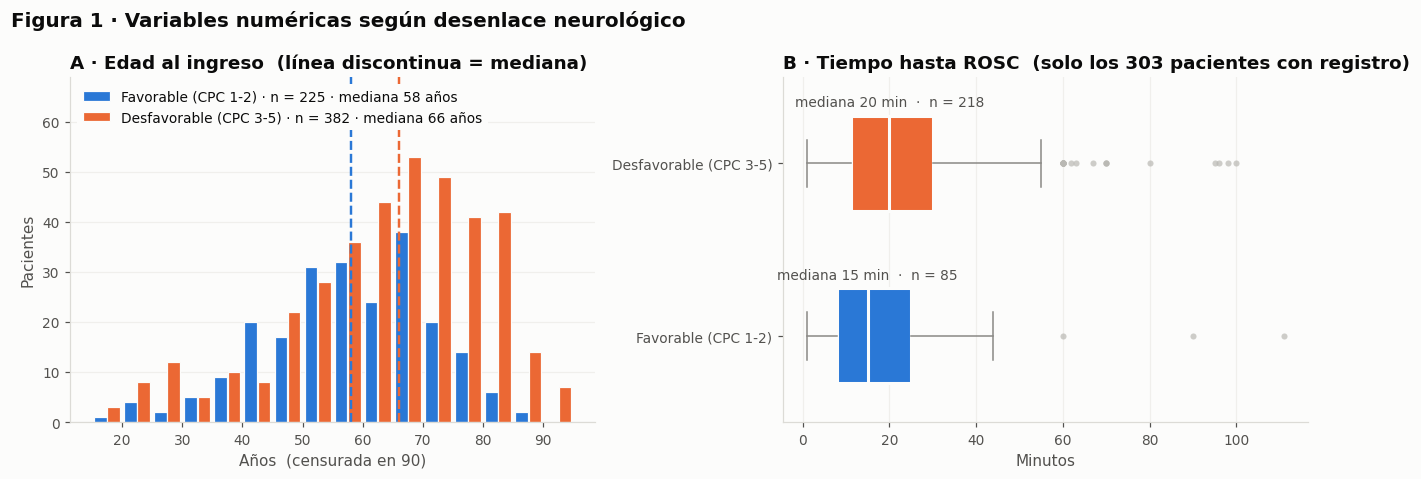

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))

# --- Panel A: edad -------------------------------------------------------
ax = axes[0]
bins = np.arange(15, 96, 5)
centros = (bins[:-1] + bins[1:]) / 2
ancho = 2.1   # deja un hueco del color de la superficie entre barras contiguas
maximo = 0
for grupo, desplaz in [("Good", -1.1), ("Poor", 1.1)]:
    serie = clinical.loc[clinical["Outcome"] == grupo, "Age"].dropna()
    conteos, _ = np.histogram(serie, bins=bins)
    maximo = max(maximo, conteos.max())
    # La mediana viaja en la leyenda para no competir con las barras por el espacio.
    ax.bar(centros + desplaz, conteos, width=ancho, color=COLOR_DESENLACE[grupo],
           label=f"{ETIQUETA_DESENLACE[grupo]} · n = {len(serie)} · "
                 f"mediana {serie.median():.0f} años",
           edgecolor=SUPERFICIE, linewidth=0.8)

ax.set_ylim(0, maximo * 1.30)
for grupo in ["Good", "Poor"]:
    ax.axvline(clinical.loc[clinical["Outcome"] == grupo, "Age"].median(),
               color=COLOR_DESENLACE[grupo], linestyle="--", linewidth=1.6)
ax.set_title("A · Edad al ingreso  (línea discontinua = mediana)", loc="left")
ax.set_xlabel("Años  (censurada en 90)")
ax.set_ylabel("Pacientes")
ax.legend(loc="upper left", frameon=True, framealpha=1,
          facecolor=SUPERFICIE, edgecolor="none")
ax.grid(axis="y", alpha=0.6)
ax.set_axisbelow(True)

# --- Panel B: tiempo hasta ROSC -----------------------------------------
ax = axes[1]
datos = [clinical.loc[(clinical["Outcome"] == g) & clinical["ROSC"].notna(), "ROSC"]
         for g in ["Good", "Poor"]]
partes = ax.boxplot(datos, vert=False, widths=0.55, patch_artist=True,
                    medianprops=dict(color=SUPERFICIE, linewidth=2),
                    flierprops=dict(marker="o", markersize=4, markerfacecolor=NEUTRO,
                                    markeredgecolor="none", alpha=0.7),
                    whiskerprops=dict(color=TINTA_3), capprops=dict(color=TINTA_3))
for caja, grupo in zip(partes["boxes"], ["Good", "Poor"]):
    caja.set_facecolor(COLOR_DESENLACE[grupo])
    caja.set_edgecolor(SUPERFICIE)
    caja.set_linewidth(2)
for i, (grupo, serie) in enumerate(zip(["Good", "Poor"], datos), start=1):
    ax.text(serie.median(), i + 0.33, f"mediana {serie.median():.0f} min  ·  n = {len(serie)}",
            ha="center", fontsize=9, color=TINTA_2)
ax.set_yticklabels([ETIQUETA_DESENLACE["Good"], ETIQUETA_DESENLACE["Poor"]])
ax.set_title("B · Tiempo hasta ROSC  (solo los 303 pacientes con registro)", loc="left")
ax.set_xlabel("Minutos")
ax.grid(axis="x", alpha=0.6)
ax.set_axisbelow(True)

fig.suptitle("Figura 1 · Variables numéricas según desenlace neurológico",
             x=0.005, ha="left", fontsize=13, fontweight="bold")
fig.tight_layout()
guardar(fig, "fig1_numericas_por_desenlace")
plt.show()

**Qué aporta.** Las dos distribuciones de edad se solapan ampliamente pese a que la diferencia de medianas (8 años) es estadísticamente muy significativa. Esa imagen es la traducción visual del tamaño de efecto rango-biserial de 0.257: la edad desplaza la distribución, pero no separa a los dos grupos. Un paciente de 60 años puede estar en cualquiera de ellos, y por eso la edad sirve para estratificar poblaciones y no para pronosticar individuos.

El panel B muestra el mismo fenómeno en el tiempo de reanimación, con la asimetría positiva visible en la cola derecha y en los valores extremos que llegan hasta 111 minutos. El desplazamiento entre medianas (15 frente a 20 minutos) es pequeño en términos absolutos, coherente con el contraste que quedó justo por encima del umbral tras la corrección de Holm.

#### **Figura 2 · Tasa de desenlace favorable por subgrupo, con incertidumbre**

La pregunta que responde: *¿qué subgrupos tienen mejor pronóstico, y cuánta confianza merece cada estimación?*

Esta es la figura central de la entrega. Cada punto es una proporción estimada y cada barra horizontal su intervalo de confianza de Wilson al 95 %: la longitud de la barra depende del tamaño del subgrupo, de modo que la figura muestra a la vez el efecto y la precisión con que se conoce.

Figura guardada en results/figures/fig2_tasas_por_subgrupo.png


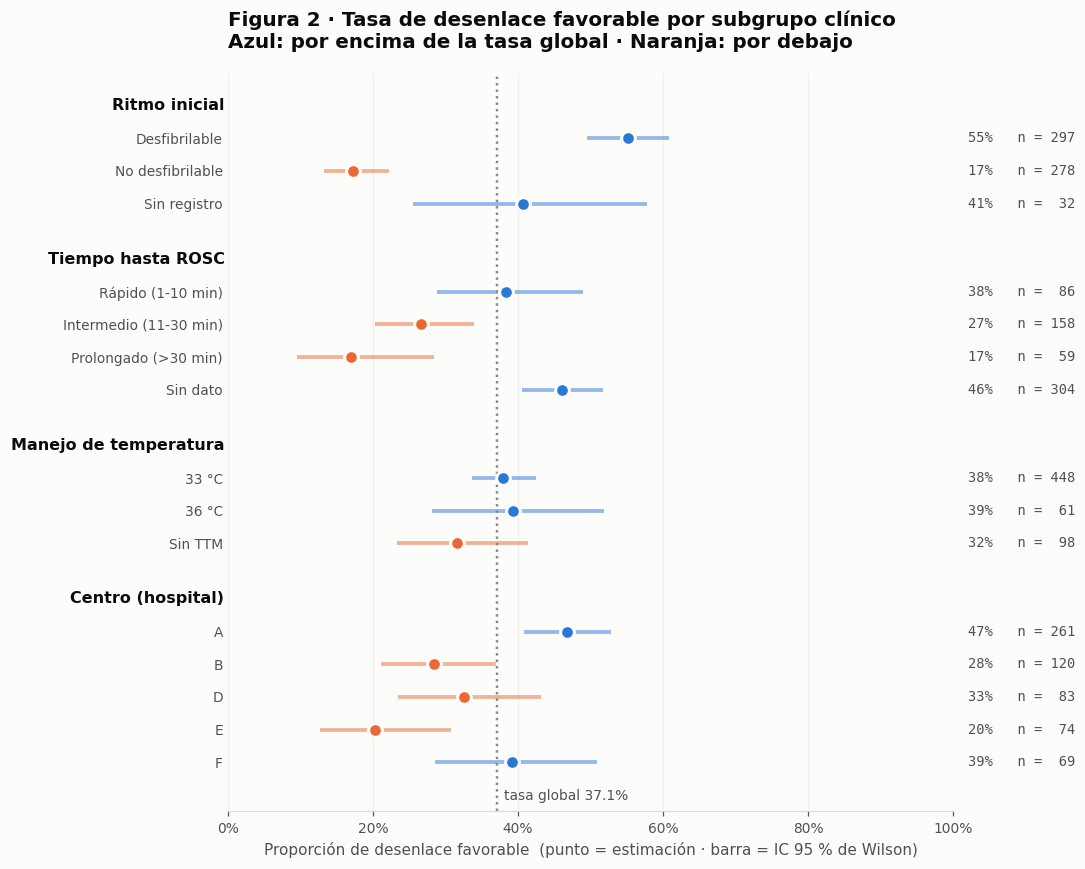

In [24]:
ETIQUETAS_NIVEL = {
    "True": "Desfibrilable", "False": "No desfibrilable", "Desconocido": "Sin registro",
}
BLOQUES = [("Shockable Rhythm", "Ritmo inicial"),
           ("ROSC_cat", "Tiempo hasta ROSC"),
           ("TTM_cat", "Manejo de temperatura"),
           ("Hospital", "Centro (hospital)")]


def tasas_por_nivel(df, variable):
    '''Proporción de desenlace favorable e IC de Wilson para cada nivel.'''
    filas = []
    for nivel, grupo in df.groupby(variable, observed=True):
        n = len(grupo)
        if n == 0:
            continue
        k = int((grupo["Outcome"] == "Good").sum())
        lo, hi = proportion_confint(k, n, method="wilson")
        filas.append({"Variable": variable, "Nivel": ETIQUETAS_NIVEL.get(str(nivel), str(nivel)),
                      "n": n, "p": k / n, "lo": lo, "hi": hi})
    if variable == "Shockable Rhythm":   # orden clínico, no alfabético
        prioridad = {"Desfibrilable": 0, "No desfibrilable": 1, "Sin registro": 2}
        filas.sort(key=lambda f: prioridad[f["Nivel"]])
    return filas


tasas = pd.DataFrame([f for var, _ in BLOQUES for f in tasas_por_nivel(clinical, var)])
p_global = (clinical["Outcome"] == "Good").mean()

# Las filas se construyen de arriba hacia abajo y el eje se invierte al final.
fig, ax = plt.subplots(figsize=(10, 8))
y = 0
posiciones, etiquetas = [], []
for var, titulo_bloque in BLOQUES:
    ax.text(-0.005, y, titulo_bloque, transform=ax.get_yaxis_transform(),
            ha="right", va="center", fontsize=10.5, fontweight="bold", color=TINTA)
    posiciones.append(y)
    etiquetas.append("")
    y += 1
    for _, fila in tasas[tasas["Variable"] == var].iterrows():
        color = FAVORABLE if fila["p"] >= p_global else DESFAVORABLE
        ax.hlines(y, fila["lo"], fila["hi"], color=color, linewidth=2.5, alpha=0.5)
        ax.plot(fila["p"], y, "o", markersize=9, color=color,
                markeredgecolor=SUPERFICIE, markeredgewidth=2, zorder=3)
        ax.text(1.02, y, f"{fila['p']:.0%}   n = {fila['n']:>3d}",
                transform=ax.get_yaxis_transform(), va="center",
                fontsize=9, color=TINTA_2, family="monospace")
        posiciones.append(y)
        etiquetas.append(fila["Nivel"])
        y += 1
    y += 0.7

ax.axvline(p_global, color=TINTA_3, linestyle=":", linewidth=1.6)
ax.text(p_global + 0.01, y - 0.55, f"tasa global {p_global:.1%}", color=TINTA_2, fontsize=9)

ax.set_yticks(posiciones)
ax.set_yticklabels(etiquetas)
ax.tick_params(axis="y", length=0)
ax.set_ylim(y - 0.2, -1)          # invertido: el primer bloque queda arriba
ax.set_xlim(0, 1)
ax.set_xlabel("Proporción de desenlace favorable  "
              "(punto = estimación · barra = IC 95 % de Wilson)")
ax.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=1))
ax.grid(axis="x", alpha=0.6)
ax.set_axisbelow(True)
ax.spines["left"].set_visible(False)

ax.set_title("Figura 2 · Tasa de desenlace favorable por subgrupo clínico\n"
             "Azul: por encima de la tasa global · Naranja: por debajo",
             loc="left", fontsize=13, pad=16)
fig.tight_layout()
guardar(fig, "fig2_tasas_por_subgrupo")
plt.show()

**Qué aporta.** Tres lecturas que ninguna tabla transmite con la misma inmediatez:

1. **La separación por ritmo inicial es la mayor del conjunto.** Los intervalos de los grupos con y sin ritmo desfibrilable ni siquiera se aproximan. Es el mismo resultado de la sección 1.3.1, ahora en forma de distancia visible.
2. **El gradiente de `ROSC_cat` es monótono.** Rápido, intermedio y prolongado se ordenan de mayor a menor tasa sin excepción, lo que respalda que el efecto estimado en la regresión no es un artefacto de la categorización. El grupo "Sin dato" no sigue ese gradiente: se sitúa por encima de todos, porque está compuesto casi por completo por pacientes del Hospital A.
3. **Los intervalos de los hospitales pequeños son anchos.** El Hospital E, con 74 pacientes, tiene un intervalo de 18 puntos de amplitud. Comparar centros leyendo solo los porcentajes llevaría a conclusiones que los datos no sostienen.

#### **Figura 3 · Estructura de asociación entre todas las variables**

La pregunta que responde: *¿qué variables comparten información, y cuáles de esas relaciones son hallazgos y cuáles artefactos del registro?*

Figura guardada en results/figures/fig3_matriz_asociacion.png


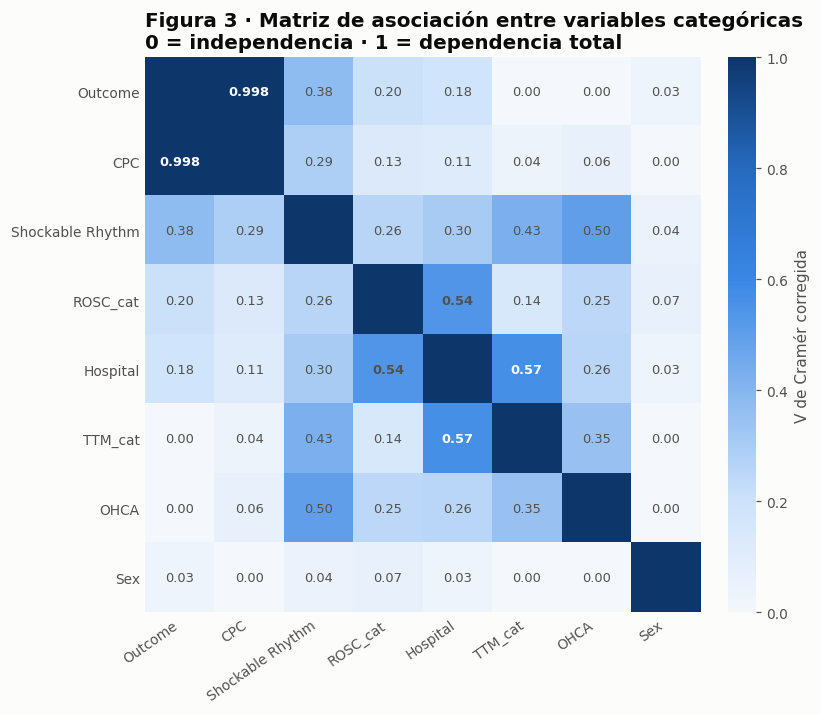

In [25]:
orden_vars = ["Outcome", "CPC", "Shockable Rhythm", "ROSC_cat", "Hospital",
              "TTM_cat", "OHCA", "Sex"]
M = matriz_v.loc[orden_vars, orden_vars]

fig, ax = plt.subplots(figsize=(7.8, 6.6))
# Rampa secuencial de un solo tono: la magnitud es lo único que codifica.
rampa = mpl.colors.LinearSegmentedColormap.from_list(
    "azul_seq", ["#f4f7fc", "#cde2fb", "#86b6ef", "#3987e5", "#256abf", "#0d366b"])
im = ax.imshow(M.values, cmap=rampa, vmin=0, vmax=1)

ax.set_xticks(range(len(orden_vars)))
ax.set_yticks(range(len(orden_vars)))
ax.set_xticklabels(orden_vars, rotation=35, ha="right")
ax.set_yticklabels(orden_vars)

for i in range(len(orden_vars)):
    for j in range(len(orden_vars)):
        v = M.values[i, j]
        if i == j:
            continue
        texto = f"{v:.3f}" if v > 0.9 else f"{v:.2f}"
        ax.text(j, i, texto, ha="center", va="center", fontsize=8.5,
                color=SUPERFICIE if v > 0.55 else TINTA_2,
                fontweight="bold" if v >= 0.5 else "normal")

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("V de Cramér corregida", color=TINTA_2)
cbar.outline.set_visible(False)

ax.set_title("Figura 3 · Matriz de asociación entre variables categóricas\n"
             "0 = independencia · 1 = dependencia total",
             loc="left", fontsize=13)
ax.tick_params(length=0)
for borde in ax.spines.values():
    borde.set_visible(False)
fig.tight_layout()
guardar(fig, "fig3_matriz_asociacion")
plt.show()

**Qué aporta.** La matriz distingue de un vistazo dos tipos de celda oscura que significan cosas opuestas:

- **La celda `Outcome` × `CPC` (0.998)** es redundancia pura: dos nombres para la misma medición. Es la que justifica que la fase 3 apartara `CPC`, y la única razón por la que ambas aparecen juntas aquí es documentarla.
- **Las celdas `Hospital` × `TTM_cat` (0.57) y `Hospital` × `ROSC_cat` (0.54)** son confusión estructural: el centro determina qué se registra y con qué protocolo se trata. No son hallazgos clínicos, pero condicionan todo el análisis, y son la razón por la que `Hospital` entra al modelo de regresión.
- **La celda `Outcome` × `Shockable Rhythm` (0.38)** es el hallazgo clínico más fuerte del conjunto.

El contraste entre la fila de `Outcome` y la de `CPC` frente a las demás variables también es informativo: ambas se comportan casi idénticamente frente al resto del conjunto, lo que confirma una vez más que son intercambiables.

#### **Figura 4 · Efectos ajustados del modelo logístico**

La pregunta que responde: *una vez controladas todas las variables entre sí, ¿cuáles conservan efecto y con qué precisión se conoce cada uno?*

Las razones de momios se representan en **escala logarítmica**, que es la escala natural de un efecto multiplicativo: en ella, duplicar y reducir a la mitad ocupan la misma distancia a cada lado de la línea de no efecto.

Figura guardada en results/figures/fig4_forest_odds_ratios.png


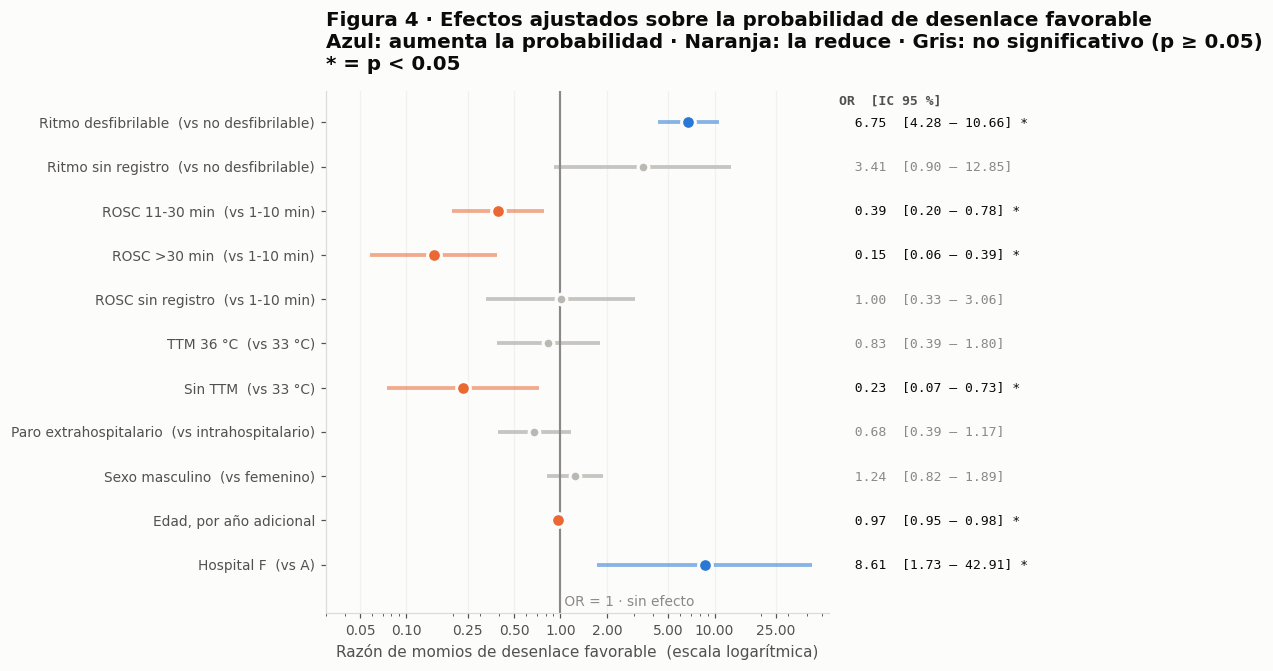

In [26]:
etiquetas_forest = {
    "C(Shockable, Treatment('False'))[T.True]": "Ritmo desfibrilable  (vs no desfibrilable)",
    "C(Shockable, Treatment('False'))[T.Desconocido]": "Ritmo sin registro  (vs no desfibrilable)",
    "C(ROSC_cat, Treatment('Rápido (1-10 min)'))[T.Intermedio (11-30 min)]": "ROSC 11-30 min  (vs 1-10 min)",
    "C(ROSC_cat, Treatment('Rápido (1-10 min)'))[T.Prolongado (>30 min)]": "ROSC >30 min  (vs 1-10 min)",
    "C(ROSC_cat, Treatment('Rápido (1-10 min)'))[T.Sin dato]": "ROSC sin registro  (vs 1-10 min)",
    "C(TTM_cat, Treatment('33 °C'))[T.36 °C]": "TTM 36 °C  (vs 33 °C)",
    "C(TTM_cat, Treatment('33 °C'))[T.Sin TTM]": "Sin TTM  (vs 33 °C)",
    "C(OHCA, Treatment('False'))[T.True]": "Paro extrahospitalario  (vs intrahospitalario)",
    "C(Sex, Treatment('Female'))[T.Male]": "Sexo masculino  (vs femenino)",
    "Age": "Edad, por año adicional",
    "C(Hospital, Treatment('A'))[T.F]": "Hospital F  (vs A)",
}

forest = pd.DataFrame({
    "OR": np.exp(logit_final.params),
    "lo": np.exp(logit_final.conf_int()[0]),
    "hi": np.exp(logit_final.conf_int()[1]),
    "p": logit_final.pvalues,
}).loc[list(etiquetas_forest)]
forest.index = [etiquetas_forest[i] for i in forest.index]
forest = forest.iloc[::-1]

fig, ax = plt.subplots(figsize=(9.6, 6.2))
for y, (nombre, fila) in enumerate(forest.iterrows()):
    significativo = fila["p"] < 0.05
    protector = fila["OR"] > 1
    color = (FAVORABLE if protector else DESFAVORABLE) if significativo else NEUTRO
    ax.hlines(y, fila["lo"], fila["hi"], color=color, linewidth=2.5,
              alpha=0.55 if significativo else 0.8)
    ax.plot(fila["OR"], y, "o", markersize=9 if significativo else 7, color=color,
            markeredgecolor=SUPERFICIE, markeredgewidth=2, zorder=3)
    ax.text(1.02, y, f"{fila['OR']:>6.2f}  [{fila['lo']:.2f} – {fila['hi']:.2f}]"
                     f"{' *' if significativo else ''}",
            transform=ax.get_yaxis_transform(), va="center", ha="left",
            fontsize=8.6, color=TINTA if significativo else TINTA_3,
            family="monospace")

ax.axvline(1, color=TINTA_3, linewidth=1.4)
ax.set_xscale("log")
ax.set_xlim(0.03, 55)
ax.set_xticks([0.05, 0.1, 0.25, 0.5, 1, 2, 5, 10, 25])
ax.get_xaxis().set_major_formatter(mpl.ticker.ScalarFormatter())
ax.set_yticks(range(len(forest)))
ax.set_yticklabels(forest.index)
ax.set_xlabel("Razón de momios de desenlace favorable  (escala logarítmica)")
ax.grid(axis="x", alpha=0.5)
ax.set_axisbelow(True)
ax.set_ylim(-1.1, len(forest) - 0.3)
ax.text(1, -0.85, " OR = 1 · sin efecto", color=TINTA_3, fontsize=9, va="center")
ax.text(1.02, len(forest) - 0.6, "OR  [IC 95 %]", transform=ax.get_yaxis_transform(),
        fontsize=8.6, color=TINTA_2, family="monospace", fontweight="bold")
ax.set_title("Figura 4 · Efectos ajustados sobre la probabilidad de desenlace favorable\n"
             "Azul: aumenta la probabilidad · Naranja: la reduce · Gris: no significativo (p ≥ 0.05)"
             "\n* = p < 0.05",
             loc="left", fontsize=13, pad=14)
fig.tight_layout()
guardar(fig, "fig4_forest_odds_ratios")
plt.show()

**Qué aporta.** La figura ordena los efectos por magnitud y muestra simultáneamente su incertidumbre, que es lo que una tabla de coeficientes comunica mal. Tres lecturas:

- El **ritmo desfibrilable** y el **tiempo prolongado hasta ROSC** son los dos efectos grandes, en direcciones opuestas, y sus intervalos están holgadamente separados de la línea de no efecto.
- El **Hospital F** tiene el punto más extremo de la figura, pero también el intervalo más ancho con diferencia: su estimación va de "casi el doble" a "más de cuarenta veces". Visualmente queda claro que es el efecto peor determinado de todos, consecuencia de sus 69 pacientes y de la colinealidad con `ROSC_cat` documentada por los VIF.
- Los efectos en gris —**sexo, paro extrahospitalario, TTM a 36 °C, ritmo sin registro**— tienen intervalos que cruzan el 1. La figura invita a leerlos como lo que son: efectos no distinguibles de cero con esta muestra, no efectos demostrados como nulos.

#### **Figura 5 · Capacidad discriminativa y calibración del modelo**

La pregunta que responde: *¿qué tan bien separa el modelo a los dos grupos, y son creíbles las probabilidades que asigna?*

Figura guardada en results/figures/fig5_roc_calibracion.png


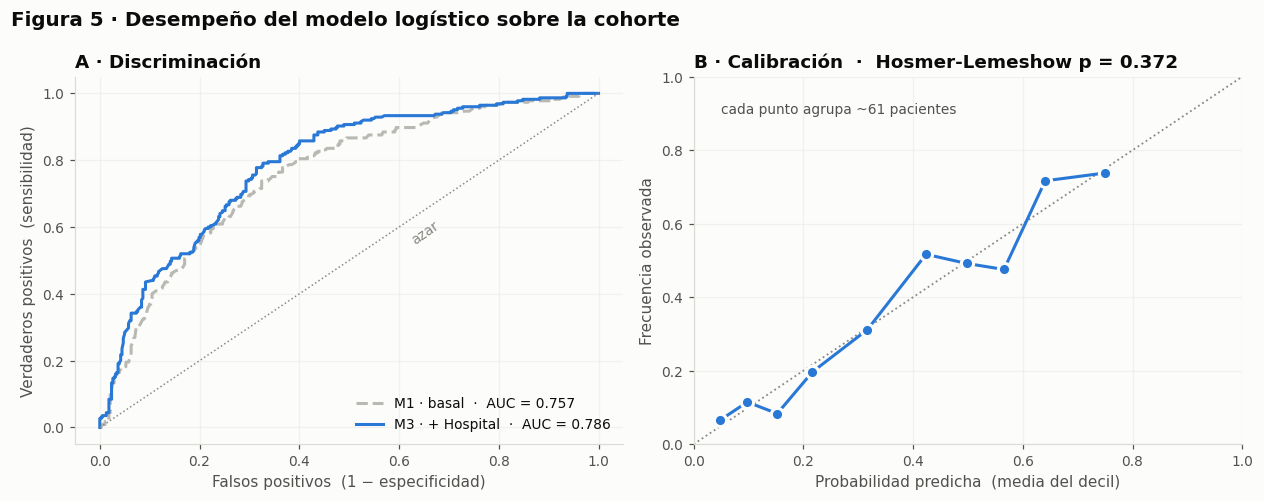

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))

# --- Panel A: curva ROC --------------------------------------------------
ax = axes[0]
for nombre, color, estilo in [("M1 · basal", NEUTRO, "--"),
                              ("M3 · + Hospital", FAVORABLE, "-")]:
    ajuste = modelos[nombre]
    fpr, tpr, _ = roc_curve(modelo_df["y"], ajuste.predict(modelo_df))
    auc = roc_auc_score(modelo_df["y"], ajuste.predict(modelo_df))
    ax.plot(fpr, tpr, color=color, linestyle=estilo, label=f"{nombre}  ·  AUC = {auc:.3f}")
ax.plot([0, 1], [0, 1], color=TINTA_3, linewidth=1, linestyle=":")
ax.text(0.62, 0.55, "azar", color=TINTA_3, fontsize=9, rotation=35)
ax.set_xlabel("Falsos positivos  (1 − especificidad)")
ax.set_ylabel("Verdaderos positivos  (sensibilidad)")
ax.set_title("A · Discriminación", loc="left")
ax.legend(loc="lower right")
ax.grid(alpha=0.5)
ax.set_axisbelow(True)

# --- Panel B: calibración por deciles ------------------------------------
ax = axes[1]
obs = hl["observados"] / hl["n"]
esp = hl["esperados"] / hl["n"]
ax.plot([0, 1], [0, 1], color=TINTA_3, linewidth=1.2, linestyle=":")
ax.plot(esp, obs, "-o", color=FAVORABLE, markersize=8,
        markeredgecolor=SUPERFICIE, markeredgewidth=2)
ax.set_xlabel("Probabilidad predicha  (media del decil)")
ax.set_ylabel("Frecuencia observada")
ax.set_title(f"B · Calibración  ·  Hosmer-Lemeshow p = {hl_p:.3f}", loc="left")
ax.text(0.05, 0.9, "cada punto agrupa ~61 pacientes", color=TINTA_2, fontsize=9)
ax.grid(alpha=0.5)
ax.set_axisbelow(True)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

fig.suptitle("Figura 5 · Desempeño del modelo logístico sobre la cohorte",
             x=0.005, ha="left", fontsize=13, fontweight="bold")
fig.tight_layout()
guardar(fig, "fig5_roc_calibracion")
plt.show()

**Qué aporta.** El panel A cuantifica la ganancia de añadir el bloque de variables de proceso: el AUC pasa de 0.757 con las cuatro variables basales a 0.786 con el modelo completo. La mejora es real —el contraste de razón de verosimilitudes la confirma— pero modesta, y la figura evita que se exagere.

El panel B es el complemento necesario del A, porque discriminación y calibración son propiedades distintas: un modelo puede ordenar bien a los pacientes y aun así asignarles probabilidades sesgadas. Los diez puntos se mantienen cerca de la diagonal, sin desviación sistemática hacia arriba ni hacia abajo, lo que significa que cuando el modelo dice "30 % de probabilidad", aproximadamente el 30 % de esos pacientes tuvo desenlace favorable.

Conviene subrayar una limitación: ambos paneles se calculan sobre los mismos datos con que se ajustó el modelo, de modo que son medidas de ajuste, no de capacidad predictiva sobre pacientes nuevos. Estimar esto último exigiría validación cruzada o una cohorte independiente, que es terreno de la fase de modelado.

#### **Figura 6 · Lo que la variable binaria oculta**

La pregunta que responde: *¿cómo se distribuye realmente la severidad neurológica dentro de cada categoría del desenlace?*

Figura guardada en results/figures/fig6_distribucion_cpc.png


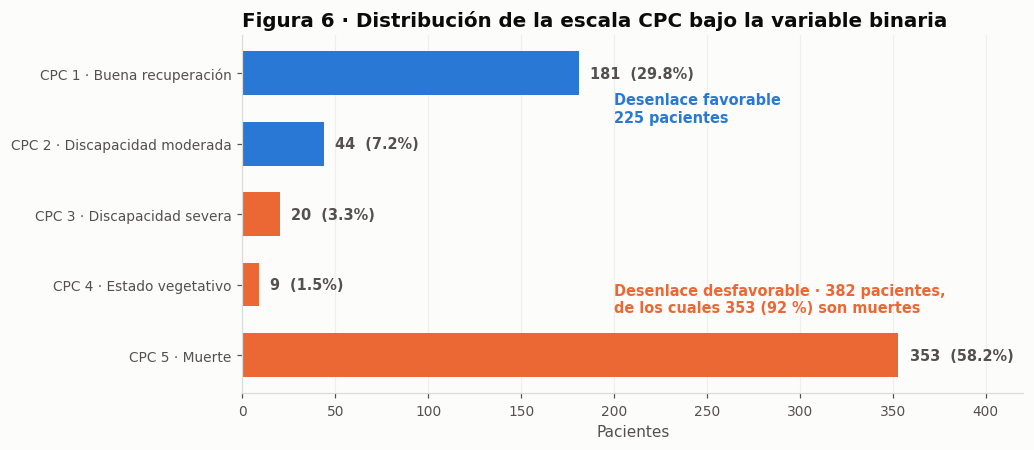

In [28]:
conteo_cpc = cpc_reference["CPC"].value_counts().sort_index()
descripcion_cpc = {
    1: "CPC 1 · Buena recuperación",
    2: "CPC 2 · Discapacidad moderada",
    3: "CPC 3 · Discapacidad severa",
    4: "CPC 4 · Estado vegetativo",
    5: "CPC 5 · Muerte",
}
colores_cpc = [FAVORABLE if nivel <= 2 else DESFAVORABLE for nivel in conteo_cpc.index]

fig, ax = plt.subplots(figsize=(9.5, 4.2))
barras = ax.barh([descripcion_cpc[i] for i in conteo_cpc.index], conteo_cpc.values,
                 color=colores_cpc, height=0.62)
for barra, valor in zip(barras, conteo_cpc.values):
    ax.text(valor + 6, barra.get_y() + barra.get_height() / 2,
            f"{valor}  ({valor/len(cpc_reference):.1%})",
            va="center", fontsize=9.5, color=TINTA_2, fontweight="bold")

ax.invert_yaxis()
ax.set_xlim(0, 420)
ax.set_xlabel("Pacientes")
ax.grid(axis="x", alpha=0.6)
ax.set_axisbelow(True)
ax.annotate("Desenlace favorable\n225 pacientes", xy=(200, 0.5), fontsize=9.5,
            color=FAVORABLE, fontweight="bold", va="center")
ax.annotate("Desenlace desfavorable · 382 pacientes,\nde los cuales 353 (92 %) son muertes",
            xy=(200, 3.2), fontsize=9.5, color=DESFAVORABLE, fontweight="bold", va="center")
ax.set_title("Figura 6 · Distribución de la escala CPC bajo la variable binaria",
             loc="left", fontsize=13)
fig.tight_layout()
guardar(fig, "fig6_distribucion_cpc")
plt.show()

**Qué aporta.** La figura hace visible el hallazgo que motivó el modelo ordinal de la sección 1.2.2: la clase "desfavorable" no es un continuo de daño neurológico, sino un bloque dominado por la mortalidad. Los niveles intermedios 3 y 4 reúnen 29 pacientes, el 4.8 % de la cohorte.

La consecuencia práctica es de diseño: un modelo entrenado sobre la variable binaria está en realidad aprendiendo a predecir mortalidad, no grado de recuperación neurológica. Quien use estos datos en una fase de modelado debe decidir explícitamente cuál de las dos preguntas quiere responder, porque la codificación de la variable de respuesta la decide por él.

### **2.2. Visualizaciones Interactivas**
---

* Cree visualizaciones interactivas, como gráficos dinámicos o tableros interactivos y proporcione instrucciones claras sobre cómo interactuar con ellos.
* Explore cómo estas visualizaciones ayudan en la exploración de datos y documente su análisis.

Las tres visualizaciones siguientes usan **Plotly** y responden a preguntas que un gráfico estático no puede atender bien: seguir un subgrupo concreto a través de varias variables, aislar un centro del resto, o descender desde el total de la cohorte hasta un nivel individual de severidad.

> **Nota de reproducción.** Si el notebook se abre sin conexión, las figuras interactivas pueden no renderizarse porque la librería se carga desde CDN. Basta con volver a ejecutar las celdas de esta sección con conexión disponible.

In [29]:
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

try:  # Colab necesita su propio renderizador
    import google.colab  # noqa: F401
    pio.renderers.default = "colab"
except ImportError:
    pio.renderers.default = "notebook_connected"

PLANTILLA = "plotly_white"
MAPA_DESENLACE = {"Good": FAVORABLE, "Poor": DESFAVORABLE}

interactivo = clinical.copy()
interactivo["Desenlace"] = interactivo["Outcome"].map(ETIQUETA_DESENLACE).astype(str)
interactivo["CPC"] = cpc_reference["CPC"]
interactivo["Ritmo"] = interactivo["Shockable Rhythm"].map(
    {"True": "Desfibrilable", "False": "No desfibrilable", "Desconocido": "Sin registro"}).astype(str)
interactivo["Paro"] = interactivo["OHCA"].map(
    {"True": "Extrahospitalario", "False": "Intrahospitalario", "Desconocido": "Sin registro"}).astype(str)
MAPA_ETIQUETAS = {ETIQUETA_DESENLACE["Good"]: FAVORABLE, ETIQUETA_DESENLACE["Poor"]: DESFAVORABLE}

print("Entorno interactivo listo · renderizador:", pio.renderers.default)

Entorno interactivo listo · renderizador: notebook_connected


#### **Interactivo 1 · Recorrido de la cohorte por las variables clínicas**

**Cómo interactuar:** arrastre verticalmente las categorías de cualquier eje para reordenarlas; haga clic y arrastre **sobre una categoría** para resaltar únicamente a los pacientes que pasan por ella y ver el resto en gris; arrastre los ejes horizontalmente para cambiar su orden y comparar pares distintos de variables.

In [30]:
interactivo["Centro"] = "Hosp. " + interactivo["Hospital"].astype(str)

fig = px.parallel_categories(
    interactivo,
    dimensions=["Centro", "Ritmo", "ROSC_cat", "TTM_cat", "Desenlace"],
    color=(interactivo["Outcome"] == "Good").astype(int),
    color_continuous_scale=[[0, DESFAVORABLE], [1, FAVORABLE]],
    labels={"Centro": "Hospital", "Ritmo": "Ritmo inicial",
            "ROSC_cat": "Tiempo hasta ROSC",
            "TTM_cat": "Manejo de temperatura", "Desenlace": "Desenlace"},
    template=PLANTILLA, height=560,
)
fig.update_layout(
    title="Interactivo 1 · Trayectoria de los 607 pacientes a través de las variables clínicas",
    coloraxis_showscale=False,
    margin=dict(l=110, r=60, t=70, b=40),
    paper_bgcolor=SUPERFICIE, plot_bgcolor=SUPERFICIE,
)
fig.show()

**Qué revela.** Al resaltar la categoría *Desfibrilable* del primer eje se ve que sus trayectorias terminan mayoritariamente en azul, mientras que las de *No desfibrilable* convergen casi todas en naranja: es el efecto de la sección 1.2.1 expresado como flujo.

El recorrido más informativo es el de la categoría **"Sin dato"** del eje de ROSC. Al resaltarla se ve que sus 304 pacientes provienen casi por completo del Hospital A —cuyo eje es el primero del gráfico—, y que ese centro no aporta prácticamente ninguna línea a los tres tramos con dato de ROSC. La confusión estructural descrita en la sección 1.1 aparece aquí como un haz de líneas que apenas se mezcla con el resto de la cohorte.

#### **Interactivo 2 · Edad y tiempo de reanimación, centro por centro**

**Cómo interactuar:** use el **menú desplegable** de la esquina superior izquierda para aislar un hospital; pase el cursor sobre cualquier punto para ver el detalle del paciente (identificador, edad, tiempo hasta ROSC, ritmo y CPC); haga clic en una entrada de la leyenda para ocultar o mostrar ese desenlace; seleccione un área con el cursor para hacer zoom, y doble clic para volver a la vista completa.

In [31]:
disp = interactivo[interactivo["ROSC"].notna()].reset_index()

fig = px.scatter(
    disp, x="Age", y="ROSC", color="Desenlace",
    color_discrete_map=MAPA_ETIQUETAS, symbol="Ritmo",
    hover_data={"Patient": True, "Hospital": True, "CPC": True,
                "Age": ":.0f", "ROSC": ":.0f", "Desenlace": False},
    labels={"Age": "Edad (años)", "ROSC": "Tiempo hasta ROSC (min)"},
    template=PLANTILLA, height=560, opacity=0.85,
)
fig.update_traces(marker=dict(size=10, line=dict(width=1.4, color=SUPERFICIE)))

# Menú desplegable: un botón por hospital, más la vista completa.
hospitales = sorted(disp["Hospital"].unique())
botones = [dict(label="Todos los centros", method="update",
                args=[{"x": [t.x for t in fig.data], "y": [t.y for t in fig.data],
                       "customdata": [t.customdata for t in fig.data]}])]
for h in hospitales:
    xs, ys, cds = [], [], []
    for t in fig.data:
        mascara = np.array([c[1] == h for c in t.customdata])
        xs.append(np.array(t.x)[mascara])
        ys.append(np.array(t.y)[mascara])
        cds.append(np.array(t.customdata)[mascara])
    botones.append(dict(label=f"Hospital {h}  (n = {int((disp['Hospital'] == h).sum())})",
                        method="update", args=[{"x": xs, "y": ys, "customdata": cds}]))

fig.update_layout(
    title="Interactivo 2 · Edad frente a tiempo hasta ROSC en los 303 pacientes con registro",
    updatemenus=[dict(buttons=botones, direction="down", x=0, xanchor="left",
                      y=1.14, yanchor="top", showactive=True,
                      bgcolor=SUPERFICIE, bordercolor="#dcdbd6")],
    legend=dict(orientation="h", y=-0.16),
    paper_bgcolor=SUPERFICIE, plot_bgcolor=SUPERFICIE,
    margin=dict(l=60, r=40, t=110, b=80),
)
fig.show()

**Qué revela.** La nube completa muestra lo que las correlaciones ya indicaban: edad y tiempo de reanimación son prácticamente independientes (ρ = −0.124), de modo que aportan información distinta sobre el mismo paciente. Los puntos azules se concentran en la esquina inferior izquierda —pacientes más jóvenes con reanimación más corta— pero sin una frontera limpia que los separe.

Al filtrar por centro aparece lo que el análisis agregado no muestra: el Hospital A **desaparece del gráfico**, porque ninguno de sus 261 pacientes tiene el dato. Esa ausencia, imposible de representar en un gráfico estático sin una nota al pie, aquí se experimenta directamente al usar el filtro.

#### **Interactivo 3 · Del total de la cohorte al nivel individual de severidad**

**Cómo interactuar:** haga clic en cualquier sector para descender un nivel (hospital → desenlace → nivel de CPC); haga clic en el círculo central para volver a subir; pase el cursor sobre un sector para ver el número de pacientes y su porcentaje respecto al total.

In [32]:
jerarquia = interactivo.copy()
jerarquia["CPC_etiqueta"] = jerarquia["CPC"].map(
    {1: "CPC 1", 2: "CPC 2", 3: "CPC 3", 4: "CPC 4", 5: "CPC 5 (muerte)"})
jerarquia["Centro"] = "Hospital " + jerarquia["Hospital"].astype(str)

fig = px.sunburst(
    jerarquia, path=["Centro", "Desenlace", "CPC_etiqueta"],
    color="Desenlace", color_discrete_map={**MAPA_ETIQUETAS, "(?)": NEUTRO},
    template=PLANTILLA, height=620,
)
fig.update_traces(
    insidetextorientation="radial",
    hovertemplate="<b>%{label}</b><br>%{value} pacientes<br>%{percentRoot:.1%} de la cohorte<extra></extra>",
    marker=dict(line=dict(color=SUPERFICIE, width=2)),
)
fig.update_layout(
    title="Interactivo 3 · Composición de la cohorte: centro → desenlace → severidad",
    paper_bgcolor=SUPERFICIE, margin=dict(t=70, l=20, r=20, b=20),
)
fig.show()

**Qué revela.** El anillo interior muestra el peso desigual de los centros: el Hospital A aporta el 43 % de la cohorte, y los cuatro restantes se reparten el resto. El anillo intermedio permite comparar la proporción de desenlace favorable entre centros sin perder de vista cuántos pacientes sostiene cada porción, que es precisamente el error que induce una tabla de porcentajes.

El anillo exterior confirma dentro de cada centro el patrón de la Figura 6: el sector de CPC 5 domina la porción desfavorable en los cinco hospitales, sin excepción. La estructura de la escala no es una particularidad de un centro, sino una característica de la cohorte completa.

### **2.3. Visualización de Mapas Coropléticos (Opcional)**
---

* Si aplica mapas coropléticos para representar datos geoespaciales, incluya estas visualizaciones.
* Explique la elección de este tipo de visualización y cómo ésta contribuye a la comprensión de patrones geográficos y a la solución planteada.

**Qué se puede y qué no se puede mapear con estos datos**

El conjunto no contiene ninguna variable geográfica a nivel de paciente. La única con componente espacial es `Hospital`, y sus valores están **anonimizados como letras A–G** precisamente para impedir identificar el centro de procedencia de cada registro. En consecuencia:

- **No es posible** representar tasas de desenlace por país o región: haría falta una correspondencia entre las letras A–G y los centros reales, que la documentación de I-CARE no publica. Construirla por inferencia sería fabricar un dato que no existe.
- **Sí es posible y pertinente** mapear la composición geográfica del consorcio que generó los datos, tomada de la documentación pública del estudio. Ese mapa no describe a los pacientes, sino **de dónde viene la evidencia**, y responde a una pregunta legítima del entendimiento del negocio: ¿a qué población puede extrapolarse lo observado?

La visualización se incluye con esa lectura explícita, y el mapa se rotula en consecuencia para que no pueda confundirse con una distribución de pacientes.

In [33]:
# Centros del consorcio I-CARE según la documentación publicada del estudio.
# Fuente: descripción del conjunto en PhysioNet (I-CARE v2.1) — no son datos del paciente.
centros = pd.DataFrame([
    {"Centro": "Rijnstate Hospital", "Ciudad": "Arnhem", "País": "Países Bajos", "ISO3": "NLD"},
    {"Centro": "Medisch Spectrum Twente", "Ciudad": "Enschede", "País": "Países Bajos", "ISO3": "NLD"},
    {"Centro": "Erasme Hospital", "Ciudad": "Bruselas", "País": "Bélgica", "ISO3": "BEL"},
    {"Centro": "Massachusetts General Hospital", "Ciudad": "Boston", "País": "Estados Unidos", "ISO3": "USA"},
    {"Centro": "Brigham and Women's Hospital", "Ciudad": "Boston", "País": "Estados Unidos", "ISO3": "USA"},
    {"Centro": "Beth Israel Deaconess Medical Center", "Ciudad": "Boston", "País": "Estados Unidos", "ISO3": "USA"},
    {"Centro": "Yale New Haven Hospital", "Ciudad": "New Haven", "País": "Estados Unidos", "ISO3": "USA"},
])

por_pais = (centros.groupby(["País", "ISO3"], as_index=False)
            .agg(Centros=("Centro", "size"),
                 Detalle=("Centro", lambda s: "<br>· " + "<br>· ".join(s))))

fig = px.choropleth(
    por_pais, locations="ISO3", color="Centros", hover_name="País",
    custom_data=["Detalle"],
    color_continuous_scale=[[0, "#cde2fb"], [0.5, "#3987e5"], [1, "#0d366b"]],
    range_color=(0, 4), template=PLANTILLA, height=520,
)
fig.update_traces(
    hovertemplate="<b>%{hovertext}</b><br>%{z} centro(s) participante(s)%{customdata[0]}<extra></extra>",
    marker_line_color=SUPERFICIE, marker_line_width=0.8,
)
fig.update_geos(showcountries=True, countrycolor="#e8e7e2",
                showland=True, landcolor="#f4f4f1", showframe=False,
                projection_type="natural earth")
fig.update_layout(
    title="Mapa · Centros del consorcio I-CARE por país<br>"
          "<sup>Representa el origen institucional del estudio, NO la distribución de los 607 pacientes, "
          "cuyo hospital está anonimizado (A–G)</sup>",
    coloraxis_colorbar=dict(title="Centros", tickvals=[1, 2, 3, 4]),
    paper_bgcolor=SUPERFICIE, margin=dict(t=90, l=10, r=10, b=10),
)
fig.show()

print(f"Centros del consorcio: {len(centros)} en {por_pais['País'].nunique()} países")
print(f"Centros representados en el conjunto público de entrenamiento: "
      f"{clinical['Hospital'].nunique()} (etiquetados "
      f"{', '.join(sorted(clinical['Hospital'].unique()))})")

Centros del consorcio: 7 en 3 países
Centros representados en el conjunto público de entrenamiento: 5 (etiquetados A, B, D, E, F)


**Qué aporta y qué no.** El mapa deja ver que la evidencia procede de siete centros terciarios de tres países de Europa occidental y Norteamérica, con clara concentración en el área de Boston. Esa composición es una **limitación de validez externa** que ningún análisis estadístico posterior puede corregir: los sistemas de emergencias, los protocolos de reanimación y los criterios de limitación del esfuerzo terapéutico de esos países no son los de otros contextos, incluido el colombiano.

El conjunto público de entrenamiento contiene además solo **cinco** de los siete centros (A, B, D, E, F), de modo que dos quedan fuera por completo. Esa ausencia refuerza la advertencia: la heterogeneidad entre centros documentada en las secciones anteriores se mide sobre una parte del consorcio, no sobre todo él.

### **2.4. Interpretación de Resultados**
---
* ¿Existen patrones o tendencias significativas en los datos?
* ¿Qué significan los resultados en términos prácticos?
* ¿Existen patrones o tendencias inesperadas en los datos que requieran una consideración especial o una investigación adicional?
* ¿Cuáles fueron los hallazgos principales que contribuirán al proceso de toma de decisiones?

**¿Existen patrones o tendencias significativas?**

Sí, y son consistentes a través de técnicas independientes. Tres variables muestran asociación con el desenlace neurológico que sobrevive tanto a la corrección por multiplicidad como al ajuste mutuo en el modelo:

| Hallazgo | Medida marginal | Efecto ajustado | Coherencia |
|---|---|---|---|
| **Ritmo inicial desfibrilable** | V = 0.379; 55.2 % vs 17.3 % de desenlace favorable | OR = 6.76 (4.28–10.66) | Se mantiene en el modelo ordinal y en el de sensibilidad |
| **Tiempo hasta ROSC** | V = 0.204; gradiente monótono | OR = 0.39 (11-30 min) y 0.15 (>30 min) vs 1-10 min | Se mantiene con la variable en escala continua |
| **Edad** | rango-biserial = 0.257; 8 años de diferencia de medianas | OR = 0.72 por década | Se mantiene en los tres modelos |

Que la ordenación de efectos no cambie al pasar de una respuesta binaria a una ordinal, ni al sustituir la categorización de `ROSC` por su versión continua, es el argumento más fuerte disponible de que estos patrones no dependen de decisiones de preparación.

**¿Qué significan en términos prácticos?**

El conjunto de variables clínicas disponibles al ingreso discrimina con un AUC de 0.786 y está bien calibrado, pero explica una fracción modesta de la variabilidad (pseudo-R² = 0.191). Traducido: **estas variables permiten estratificar poblaciones, no pronosticar individuos.** La Figura 1 lo muestra sin ambigüedad —las distribuciones de edad de ambos grupos se solapan casi por completo—, y es exactamente el vacío que justifica el proyecto: si los datos clínicos bastaran, no haría falta el EEG.

Para una decisión clínica individual, un modelo de este desempeño no es utilizable. Para diseñar un estudio, seleccionar subgrupos de riesgo o construir la línea base contra la que se medirá el aporte de las señales fisiológicas, sí lo es.

**¿Hay patrones inesperados que requieran atención?**

Tres, y los tres apuntan a la misma dirección:

1. **La ausencia de `ROSC` no codifica gravedad, codifica procedencia.** Una vez ajustado por hospital, el grupo "Sin dato" es indistinguible del de reanimación rápida (OR = 1.005; IC 0.33–3.06). Sin ese ajuste, aparentaba mejor pronóstico. Es un caso de libro de cómo un patrón de datos faltantes puede simular un hallazgo clínico.
2. **El efecto de no recibir TTM aparece solo tras el ajuste** (OR = 0.23; *p* = 0.012), mientras que el contraste marginal no detectaba nada. La explicación más plausible no es terapéutica sino de selección: en un diseño observacional, no aplicar manejo de temperatura suele ser consecuencia del estado del paciente. Requiere investigación adicional con información sobre el momento y el motivo de la decisión, que este conjunto no contiene.
3. **La clase "desfavorable" es, en un 92 %, mortalidad.** Los niveles intermedios de CPC reúnen 29 pacientes. Cualquier modelo entrenado sobre la variable binaria estará aprendiendo a predecir muerte, no grado de recuperación neurológica.

**¿Qué hallazgos contribuyen a la toma de decisiones?**

Para la continuación del proyecto:

- **Línea base establecida.** AUC = 0.786 con variables clínicas es el umbral que el análisis de EEG deberá superar para justificar su costo de procesamiento. Sin esta referencia, cualquier resultado posterior sería incomparable.
- **`Hospital` es una variable de control obligatoria**, no opcional. Los VIF muestran que centro y disponibilidad de `ROSC` no son separables en esta cohorte; omitir el centro contaminaría los coeficientes de las variables clínicas.
- **La muestra de EEG debe estratificarse por centro y por desenlace.** Con tasas de desenlace favorable que van del 20.3 % al 46.7 % entre hospitales y una diferencia de precisión de 6 puntos en la amplitud de los intervalos, un muestreo simple produciría una submuestra sesgada.
- **La variable de respuesta debe elegirse de forma explícita.** Binaria si la pregunta es supervivencia con recuperación; ordinal sobre `CPC` si es grado de daño neurológico. No son la misma pregunta y el 92 % de mortalidad en la clase desfavorable hace que la diferencia importe.

### **Cumplimiento de objetivos**
---

Los objetivos que esta fase debía atender, y su estado al cierre:

| Objetivo (del planteamiento del proyecto) | Estado | Evidencia en este notebook |
|---|---|---|
| Describir la distribución de edad, ROSC, TTM y desenlace en la población analizada | **Cumplido** | Tabla de características (1.0.1), Figuras 1 y 6 |
| Analizar la relación entre variables clínicas y el desenlace neurológico | **Cumplido** | Matriz de asociación (1.1), modelos de regresión (1.2), contrastes (1.3) |
| Cuantificar la incertidumbre de las estimaciones obtenidas | **Cumplido** | IC de Wilson y *bootstrap* (1.3.1), Figuras 2 y 4 |
| Verificar que los hallazgos no dependen de decisiones de preparación | **Cumplido** | Modelo ordinal (1.2.2) y análisis de sensibilidad (1.2.4) |
| Documentar el efecto de la heterogeneidad entre centros | **Cumplido** | VIF (1.2.1), contraste de modelos anidados, Figura 2, mapa (2.3) |
| Establecer una línea base contra la cual medir el aporte del EEG | **Cumplido** | AUC = 0.786 y calibración (Figura 5) |
| Caracterizar las señales EEG y extraer características espectrales | **Fuera del alcance de esta fase** | La preparación de la rama fisiológica quedó documentada en la fase 3; su análisis corresponde a la fase siguiente |

El único objetivo no atendido es deliberado: el análisis de las señales EEG exige descargar los registros desde PhysioNet y procesarlos, trabajo cuyo alcance excede esta entrega y que la fase 3 dejó ya preparado con la selección de registros, la ventana temporal y el filtrado validados.

## **3. Conclusiones**
---

1. **Sobre las técnicas estadísticas y su elección.** La composición mixta del conjunto —dos numéricas, una ordinal, cinco nominales y una respuesta binaria— descarta un enfoque único de correlación. Emplear V de Cramér para pares categóricos, ρ de Spearman para ordinales y pruebas de rango para las comparaciones numéricas no fue una preferencia metodológica sino una consecuencia del tipo de dato: aplicar Pearson de forma indiscriminada habría producido coeficientes sin interpretación sobre siete de las ocho variables analizadas.

2. **Sobre el análisis de correlaciones.** La estructura de asociación del conjunto contiene dos tipos de dependencia que no deben confundirse. La redundancia entre `Outcome` y `CPC` (V = 0.998) es informativa sobre cómo se construyó la base y obliga a no usarlas juntas. Las asociaciones entre `Hospital` y las variables de proceso (V = 0.54 y 0.57) son confusión estructural: no aportan información clínica, pero determinan qué modelos son interpretables. Distinguir ambas fue el paso que permitió especificar correctamente la regresión.

3. **Sobre el análisis de regresiones.** El modelo logístico ajustado identifica tres efectos robustos —ritmo desfibrilable (OR = 6.76), gradiente de tiempo hasta ROSC (OR = 0.39 y 0.15) y edad (OR = 0.72 por década)— con un AUC de 0.786 y calibración adecuada (Hosmer-Lemeshow *p* = 0.372). Los contrastes de modelos anidados justifican la inclusión de cada bloque de variables, y la coincidencia con el modelo ordinal sobre `CPC` y con el análisis de sensibilidad sobre la submuestra con `ROSC` observado confirma que los hallazgos no dependen de cómo se codificó la respuesta ni de cómo se trataron los faltantes.

4. **Sobre la estadística inferencial.** Cuatro de ocho hipótesis nulas se rechazan tras la corrección de Holm, y las cuatro con *p* muy por debajo del umbral. El caso de `ROSC` como variable continua (*p* = 0.013 sin corregir, 0.052 corregido) ilustra por qué la corrección es necesaria: sin ella, la batería de contrastes tendría un 34 % de probabilidad de producir al menos un falso positivo. Reportar cada *p*-valor junto a su tamaño de efecto e intervalo de confianza evita además el error inverso, el de confundir significación estadística con relevancia clínica en una muestra de 607 casos.

5. **Sobre las visualizaciones.** Las seis figuras estáticas y las tres interactivas están construidas sobre un único sistema de color y forma, en el que el azul y el naranja codifican siempre lo mismo. Las interactivas aportan lo que las estáticas no pueden: el filtro por hospital del segundo gráfico hace evidente, al usarlo, que el Hospital A desaparece del análisis de `ROSC`, y el recorrido de categorías del primero muestra el grupo "Sin dato" como un haz que no se mezcla con el resto de la cohorte.

6. **Sobre el cumplimiento de los objetivos y lo que sigue.** El análisis establece la línea base clínica que el proyecto necesitaba: con las variables disponibles al ingreso se alcanza un AUC de 0.786, suficiente para estratificar poblaciones e insuficiente para pronosticar pacientes. Esa brecha, junto con la advertencia de que la clase desfavorable es en un 92 % mortalidad, define con precisión qué debe aportar el análisis de las señales EEG en la fase siguiente y contra qué referencia se medirá.

## **Créditos**
* **Profesor:** [Felipe Restrepo Calle](https://dis.unal.edu.co/~ferestrepoca/)
* **Asistentes docentes:**
    - [Juan Sebastián Lara Ramírez](https://www.linkedin.com/in/juan-sebastian-lara-ramirez-43570a214/).
* **Diseño de imágenes:**
    - [Rosa Alejandra Superlano Esquibel](mailto:rsuperlano@unal.edu.co).
* **Coordinador de virtualización:**
    - [Edder Hernández Forero](https://www.linkedin.com/in/edder-hernandez-forero-28aa8b207/).

**Universidad Nacional de Colombia** - *Facultad de Ingeniería*